# Code to analyze glacier elevation change (dH) rasters for Nevados de Chillán 
### performing geostpatial statistical analysis 

In [5]:
# Import packages 
import os
import glob
import shutil
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import transform_bounds
from rasterio.windows import Window
from rasterio.transform import xy
from shapely.geometry import mapping

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
import seaborn as sns
import contextily as ctx
from scipy import stats
from scipy.stats import pearsonr
from esda.moran import Moran, Moran_Local
from libpysal.weights import lat2W

## Step 1: Compute mean slope, aspect, and elevation of each glacier, analyze whether elevation change is correlated with geospatial variable
### Question: is there a statistical relationship between glacier geography (mean elevation, aspect, slope) and mean glacier elevation loss?

In [6]:
# --------- USER SETTINGS ---------
csv_folder = "/Users/milliespencer/Glacier-DEM-coregistration-and-MB"
file_pattern = os.path.join(csv_folder, "*_summary.csv")
output_folder = os.path.join(csv_folder, "correlation_analysis")
os.makedirs(output_folder, exist_ok=True)

# --------- HELPER FUNCTIONS ---------

def calculate_and_plot_correlations(df, raster_label, output_folder):
    """
    For a given dataframe, compute and plot correlations between dH and terrain attributes.
    """
    results = []
    for var in ['elevation_mean', 'slope_mean', 'aspect_mean']:
        try:
            r, p = pearsonr(df['dH_mean'], df[var])
            results.append({
                "Raster": raster_label,
                "Variable": var,
                "Pearson_r": r,
                "p_value": p
            })

            sns.regplot(data=df, x=var, y='dH_mean', scatter_kws={'alpha': 0.5})
            plt.title(f"{raster_label}: dH_mean vs {var}\nPearson r = {r:.2f}, p = {p:.3f}")
            plt.xlabel(var)
            plt.ylabel("Mean dH (m)")
            plt.tight_layout()
            plot_path = os.path.join(output_folder, f"{raster_label}_{var}_correlation.png")
            plt.savefig(plot_path)
            plt.close()
            print(f"📈 Saved plot: {plot_path}")

        except Exception as e:
            print(f"⚠️ Could not calculate correlation for {raster_label} vs {var}: {e}")
    return results

def extract_years_from_label(label):
    """
    Extract raster year and glacier year from a filename label.
    Expects parts like '..._2019_glaciers2019_...' or '..._2000_glaciers2000_...'
    """
    parts = label.split('_')
    raster_year = None
    glacier_year = None
    
    for p in parts:
        if p in ['2000', '2019']:
            raster_year = p
        elif p.startswith('glaciers'):
            year_part = p.replace('glaciers', '')
            if year_part in ['2000', '2019']:
                glacier_year = year_part

    return raster_year, glacier_year

# --------- MAIN ANALYSIS ---------

def main():
    all_results = []

    for filepath in glob.glob(file_pattern):
        filename = os.path.basename(filepath)
        raster_label = filename.replace("_summary.csv", "")

        raster_year, glacier_year = extract_years_from_label(raster_label)

        if raster_year is None or glacier_year is None:
            print(f"⚠️ Cannot determine years for {filename}, skipping.")
            continue

        if raster_year != glacier_year:
            print(f"⚠️ Skipping {filename} because raster year ({raster_year}) != glacier year ({glacier_year})")
            continue

        print(f"\n🔍 Analyzing: {raster_label}")

        try:
            df = pd.read_csv(filepath)
            df = df.dropna(subset=['dH_mean', 'slope_mean', 'aspect_mean', 'elevation_mean'])
            if df.empty:
                print(f"⚠️ Skipped {raster_label} (no valid data)")
                continue

            res = calculate_and_plot_correlations(df, raster_label, output_folder)
            all_results.extend(res)

        except Exception as e:
            print(f"⚠️ Error reading {filename}: {e}")
            continue

    results_df = pd.DataFrame(all_results)
    results_csv = os.path.join(output_folder, "correlation_summary.csv")
    results_df.to_csv(results_csv, index=False)
    print(f"\n✅ Saved correlation summary table to: {results_csv}")


if __name__ == "__main__":
    main()

⚠️ Cannot determine years for CAMELS_CL_Basin8130002_trends_summary.csv, skipping.

✅ Saved correlation summary table to: /Users/milliespencer/Glacier-DEM-coregistration-and-MB/correlation_analysis/correlation_summary.csv


### Result: no statistically significant relationship between mean glacier elevation, aspect, or slope and mean glacier elevation loss. Our data does not suggest a relationship between a glacier's elevation loss and its geographic attributes. 

## Step 2: Let's look at the pixel level, not just glaciers or whole subcomplexes
## Here we: analyze dH per pixel, and calculate mean, median, and standard deviation of dH 

✅ Combined pixel data saved to: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats/All_dH_pixels_combined.csv


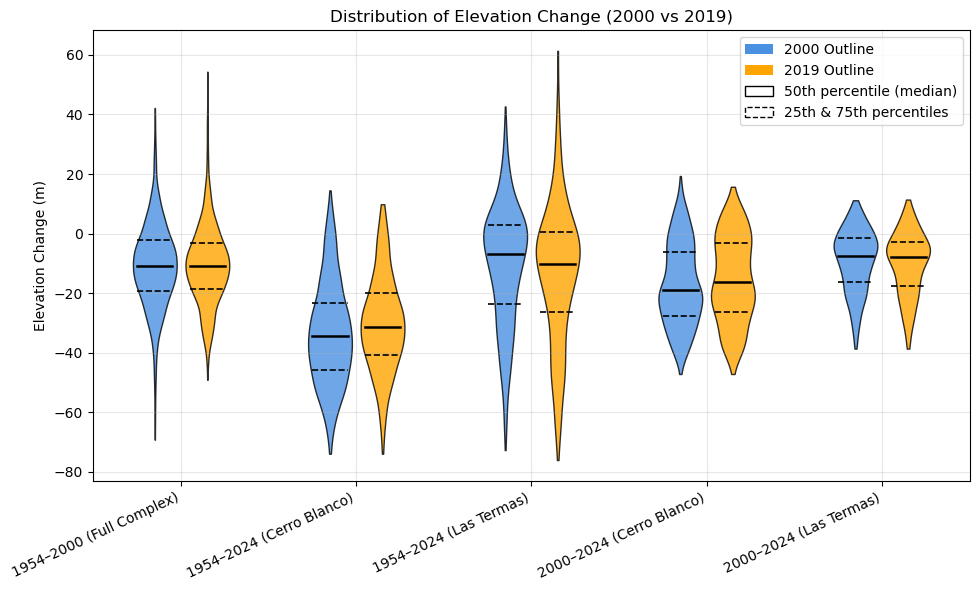

In [7]:
# ------------------------------------------
# Glacier outlines
# ------------------------------------------
glacier_outlines = {
    "2000": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp",
    "2019": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"
}

# ------------------------------------------
# Elevation difference rasters
# ------------------------------------------
base_dir = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated"

raster_paths = {
    "SRTMminusIGM": {
        "2000": f"{base_dir}/output_data_baseIGM_poly2000_updated/SRTM_projected_raste_clp_diff.tif",
        "2019": f"{base_dir}/output_data_baseIGM_poly2019_updated/SRTM_projected_raste_clp_diff.tif"
    },
    "CBminusSRTM": {
        "2000": f"{base_dir}/output_data_baseSRTM_poly2000/CerroBlanco_DEMproje_clp_diff.tif",
        "2019": f"{base_dir}/output_data_baseSRTM_poly2019/CerroBlanco_DEMproje_clp_diff.tif"
    },
    "LTminusSRTM": {
        "2000": f"{base_dir}/output_data_baseSRTM_poly2000/LasTermas_DEMproject_clp_diff.tif",
        "2019": f"{base_dir}/output_data_baseSRTM_poly2019/LasTermas_DEMproject_clp_diff.tif"
    },
    "CBminusIGM": {
        "2000": f"{base_dir}/output_data_baseIGM_poly2000_updated/CerroBlanco_DEMproje_clp_diff.tif",
        "2019": f"{base_dir}/output_data_baseIGM_poly2019_updated/CerroBlanco_DEMproje_clp_diff.tif"
    },
    "LTminusIGM": {
        "2000": f"{base_dir}/output_data_baseIGM_poly2000_updated/LasTermas_DEMproject_clp_diff.tif",
        "2019": f"{base_dir}/output_data_baseIGM_poly2019_updated/LasTermas_DEMproject_clp_diff.tif"
    }
}

# ------------------------------------------
# Function: Extract valid elevation change pixels
# ------------------------------------------
def extract_valid_pixels(raster_path, glacier_polygon):
    """Extract valid elevation change values from raster within a polygon."""
    if glacier_polygon is None:
        return np.array([])

    try:
        with rasterio.open(raster_path) as src:
            out_image, _ = mask(src, [mapping(glacier_polygon)], crop=True)
            arr = out_image[0]
            arr = np.where((arr >= 1e38) | (arr <= -9999), np.nan, arr)
            return arr.flatten()
    except ValueError as e:
        if "Input shapes do not overlap raster" in str(e):
            return np.array([])
        else:
            raise e
    except Exception as e:
        print(f"Error masking {raster_path}: {e}")
        return np.array([])

# ------------------------------------------
# Extract pixels and build combined DataFrame
# ------------------------------------------
output_dir = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"
os.makedirs(output_dir, exist_ok=True)

records = []

for comp_name, comp_rasters in raster_paths.items():
    for year, raster_path in comp_rasters.items():
        gdf = gpd.read_file(glacier_outlines[year])
        all_pixels = []

        for _, row in gdf.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue
            pixels = extract_valid_pixels(raster_path, row.geometry)
            valid_pixels = pixels[~np.isnan(pixels)]
            all_pixels.extend(valid_pixels)

        all_pixels = np.array(all_pixels)
        if all_pixels.size == 0:
            print(f"⚠️ No valid pixels for {comp_name} ({year})")
            continue

        for val in all_pixels:
            records.append({
                "Comparison": comp_name,
                "YearOutline": year,
                "dH": val
            })

# Convert to DataFrame
df = pd.DataFrame(records)
csv_path = os.path.join(output_dir, "All_dH_pixels_combined.csv")
df.to_csv(csv_path, index=False)
print(f"✅ Combined pixel data saved to: {csv_path}")

# ------------------------------------------
# Plot violin plots (blue = 2000, orange = 2019)
# ------------------------------------------
plt.figure(figsize=(10, 6))

# Explicit order and custom labels
ordered_comparisons = ["SRTMminusIGM", "CBminusIGM", "LTminusIGM", "CBminusSRTM", "LTminusSRTM"]
custom_labels = [
    "1954–2000 (Full Complex)",
    "1954–2024 (Cerro Blanco)",
    "1954–2024 (Las Termas)",
    "2000–2024 (Cerro Blanco)",
    "2000–2024 (Las Termas)"
]

color_2000 = "#4A90E2"  # blue
color_2019 = "#FFA500"  # orange

for i, comp in enumerate(ordered_comparisons, 1):
    subset = df[df["Comparison"] == comp]
    data_2000 = subset[subset["YearOutline"] == "2000"]["dH"].dropna()
    data_2019 = subset[subset["YearOutline"] == "2019"]["dH"].dropna()

    # Create two violins for each comparison (blue/orange)
    for data, color, offset in [(data_2000, color_2000, -0.15), (data_2019, color_2019, 0.15)]:
        if data.empty:
            continue

        parts = plt.violinplot(
            [data],
            positions=[i + offset],
            widths=0.25,
            showmeans=False,
            showextrema=False
        )

        for body in parts['bodies']:
            body.set_facecolor(color)
            body.set_edgecolor("black")
            body.set_alpha(0.8)

        # Add percentiles (25th, 50th, 75th)
        q25, q50, q75 = np.percentile(data, [25, 50, 75])
        for y in [q25, q75]:
            plt.plot([i + offset - 0.1, i + offset + 0.1], [y, y],
                     linestyle='--', color='k', linewidth=1.2)
        plt.plot([i + offset - 0.1, i + offset + 0.1], [q50, q50],
                 linestyle='-', color='k', linewidth=1.8)

# Final plot formatting
plt.xticks(range(1, len(ordered_comparisons) + 1), custom_labels, rotation=25, ha='right')
plt.ylabel("Elevation Change (m)")
plt.title("Distribution of Elevation Change (2000 vs 2019)")
plt.grid(alpha=0.3)

# Legend
legend_elements = [
    Patch(facecolor=color_2000, label='2000 Outline'),
    Patch(facecolor=color_2019, label='2019 Outline'),
    Patch(facecolor='none', edgecolor='black', linestyle='-', label='50th percentile (median)'),
    Patch(facecolor='none', edgecolor='black', linestyle='--', label='25th & 75th percentiles')
]
plt.legend(handles=legend_elements, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


## does the choice of 2000 or 2019 outline have a significant impact on glacier elevation change?

In [8]:
import os
import re
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

# ----------------------------
# Config
# ----------------------------
pixel_stats_dir = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"
output_csv = os.path.join(pixel_stats_dir, "t_test_results.csv")

# ----------------------------
# Helper: identify year and true base
# ----------------------------
def detect_year_and_base(fname):
    """
    Find the last occurrence of '_2000' or '_2019' (or '-2000'/'-2019'),
    treat that as the year token, and return (base, year).
    Example: 'CBminusIGM_2000_pixels.csv' -> ('CBminusIGM', '2000')
    """
    name = fname.rsplit("/", 1)[-1]  # strip path if present
    name_noext = re.sub(r'\.csv$', '', name, flags=re.IGNORECASE)

    # search for the last occurrence of the year token
    match_2000 = [m.start() for m in re.finditer(r'[_\-]2000(?:_|$)', name_noext)]
    match_2019 = [m.start() for m in re.finditer(r'[_\-]2019(?:_|$)', name_noext)]

    if match_2000 and (not match_2019 or match_2000[-1] > (match_2019[-1] if match_2019 else -1)):
        idx = match_2000[-1]
        year = "2000"
    elif match_2019:
        idx = match_2019[-1]
        year = "2019"
    else:
        return None, None

    # base is everything before the separator just before the year token
    # e.g., "CBminusIGM_2000_pixels" -> base = "CBminusIGM"
    # find the separator underscore or dash position at idx, strip it
    sep_pos = idx
    base = name_noext[:sep_pos]
    # remove trailing separators if present
    base = re.sub(r'[_\-]+$', '', base)
    return base, year

# ----------------------------
# Discover files and group by true base
# ----------------------------
all_files = [f for f in os.listdir(pixel_stats_dir) if f.lower().endswith(".csv")]
groups = {}  # base -> {'2000': path, '2019': path}

for fname in all_files:
    base, year = detect_year_and_base(fname)
    if base is None:
        # ignore CSVs that don't include 2000/2019 token
        continue
    groups.setdefault(base, {})[year] = os.path.join(pixel_stats_dir, fname)

# ----------------------------
# Load function (flexible column detection)
# ----------------------------
def load_dh(path):
    df = pd.read_csv(path)
    # try common column names
    for col in ["dh", "dH", "d_h", "deltah", "dh_m", "value", "dH_m"]:
        if col in df.columns:
            return df[col].dropna().to_numpy()
    # fallback: first numeric column
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) == 0:
        raise ValueError(f"No numeric column found in {path}")
    return df[numeric_cols[0]].dropna().to_numpy()

# ----------------------------
# Perform tests
# ----------------------------
results = []
missing = []

for base, yrs in sorted(groups.items()):
    has2000 = "2000" in yrs
    has2019 = "2019" in yrs
    if not (has2000 and has2019):
        missing.append((base, has2000, has2019))
        continue

    p2000 = yrs["2000"]
    p2019 = yrs["2019"]

    try:
        data2000 = load_dh(p2000)
        data2019 = load_dh(p2019)
    except Exception as e:
        print(f"❌ Failed loading {base}: {e}")
        continue

    n1 = data2000.size
    n2 = data2019.size

    if n1 == 0 or n2 == 0:
        print(f"⚠️ Empty sample for {base}: n2000={n1}, n2019={n2}. Skipping.")
        continue

    mean1 = float(np.mean(data2000))
    mean2 = float(np.mean(data2019))
    sd1 = float(np.std(data2000, ddof=1))
    sd2 = float(np.std(data2019, ddof=1))

    # Welch's t-test
    t_stat, p_val = ttest_ind(data2000, data2019, equal_var=False)

    # Cohen's d (pooled SD)
    pooled_var = (((n1 - 1) * sd1**2) + ((n2 - 1) * sd2**2)) / (n1 + n2 - 2) if (n1 + n2 - 2) > 0 else np.nan
    pooled_sd = np.sqrt(pooled_var) if not np.isnan(pooled_var) else np.nan
    cohen_d = float((mean1 - mean2) / pooled_sd) if pooled_sd and not np.isnan(pooled_sd) else np.nan

    results.append({
        "Raster_base": base,
        "n_2000": n1,
        "n_2019": n2,
        "Mean_2000": mean1,
        "Mean_2019": mean2,
        "SD_2000": sd1,
        "SD_2019": sd2,
        "t_stat": float(t_stat),
        "p_value": float(p_val),
        "cohen_d": cohen_d
    })

# ----------------------------
# Save & print
# ----------------------------
if results:
    df_out = pd.DataFrame(results).sort_values("Raster_base").reset_index(drop=True)
    df_out.to_csv(output_csv, index=False)
    print("\n📊 T-Test Results Comparing 2000 vs 2019 Outlines:")
    print(df_out.round({
        "Mean_2000":4, "Mean_2019":4, "SD_2000":4, "SD_2019":4,
        "t_stat":4, "p_value":6, "cohen_d":4
    }).to_string(index=False))
    print(f"\nSaved results to: {output_csv}")
else:
    print("No matched pairs found to test.")

if missing:
    print("\n⚠️ The following raster bases are missing one of the years (base, has2000, has2019):")
    for rec in missing:
        print("  -", rec)



📊 T-Test Results Comparing 2000 vs 2019 Outlines:
 Raster_base  n_2000  n_2019  Mean_2000  Mean_2019  SD_2000  SD_2019  t_stat  p_value  cohen_d
  CBminusIGM     764     656   -33.4335   -30.2471  17.2481  16.0930 -3.5982 0.000332  -0.1905
 CBminusSRTM     764     656   -17.0239   -15.2855  13.8241  14.4524 -2.3056 0.021284  -0.1231
  LTminusIGM     649     460   -10.6066   -13.0643  20.1240  23.3953  1.8249 0.068355   0.1141
 LTminusSRTM     649     460    -9.0774   -10.1609  10.5361  10.6569  1.6761 0.094038   0.1024
SRTMminusIGM    3224    2119   -10.8954   -10.6530  14.2961  13.3405 -0.6313 0.527859  -0.0174

Saved results to: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats/t_test_results.csv

⚠️ The following raster bases are missing one of the years (base, has2000, has2019):
  - ('SRTMminusIGM_2019', True, False)
  - ('t_test_results_2000_vs', False, True)


Cerro Blanco glaciers are sensitive to outline selection: newer (2019) outlines slightly reduce estimated mass loss. Las Termas glaciers are less sensitive; outline choice doesn’t substantially change the Δh distribution. Overall effect: small but measurable differences; effect sizes are small (|d| < 0.2), so while statistically detectable, the impact is modest.


📂 Year: 2000
🔵 Raster: SRTMminusIGM_2000


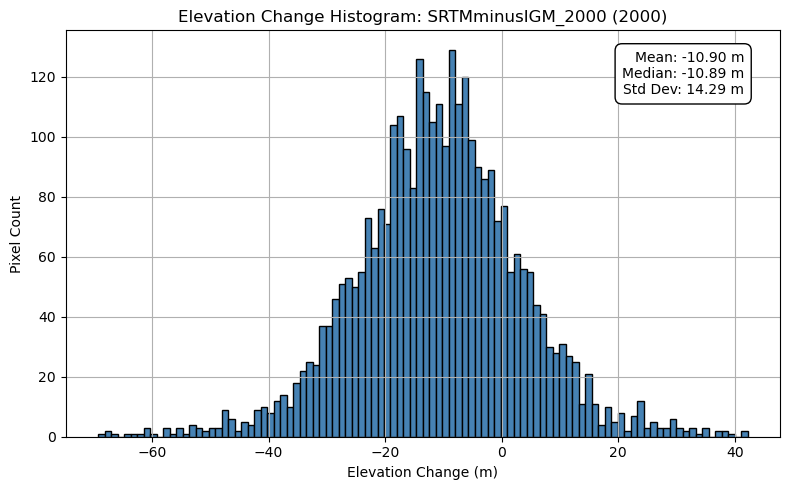


📂 Year: 2000
🔵 Raster: CBminusSRTM_2000


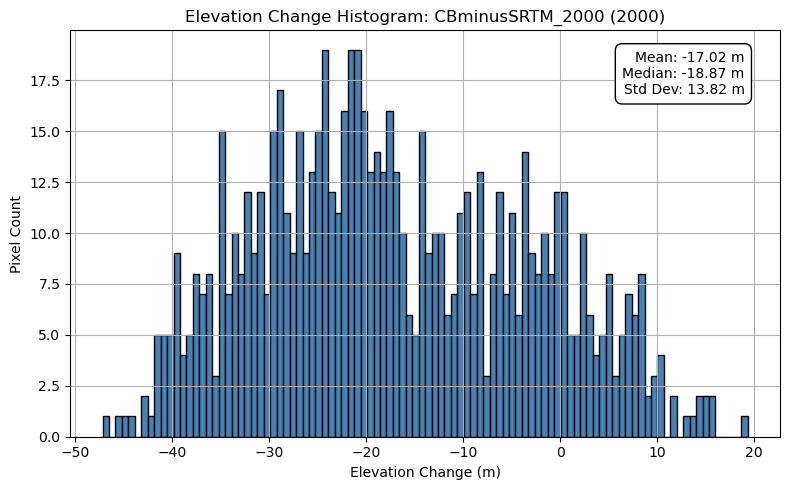


📂 Year: 2000
🔵 Raster: LTminusSRTM_2000


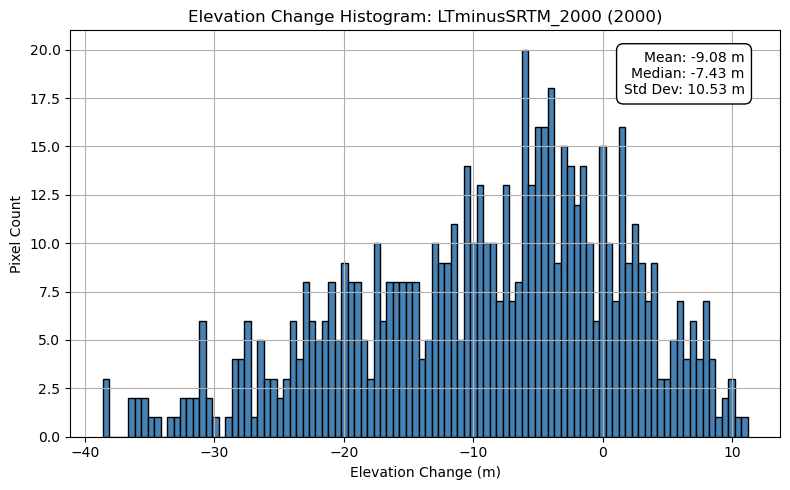


📂 Year: 2000
🔵 Raster: CBminusIGM_2000


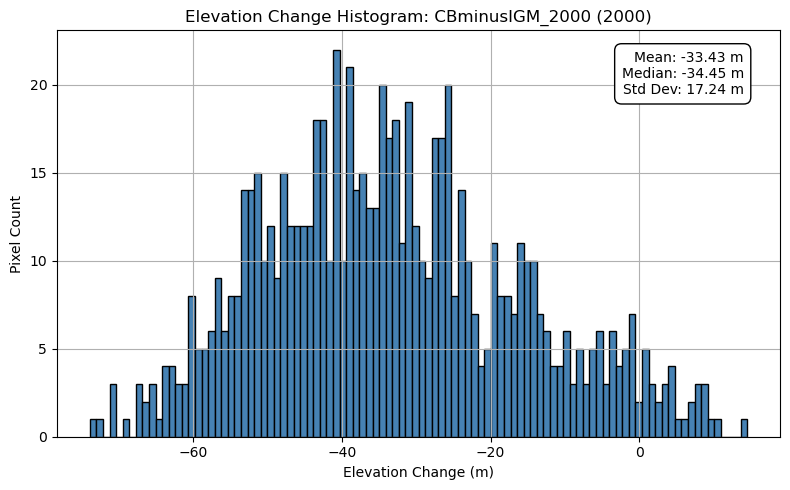


📂 Year: 2000
🔵 Raster: LTminusIGM_2000


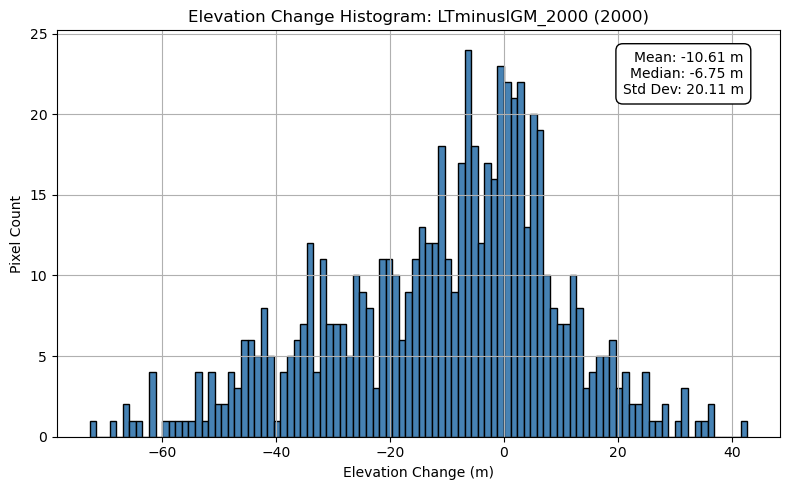


📂 Year: 2019
🔵 Raster: SRTMminusIGM_2019


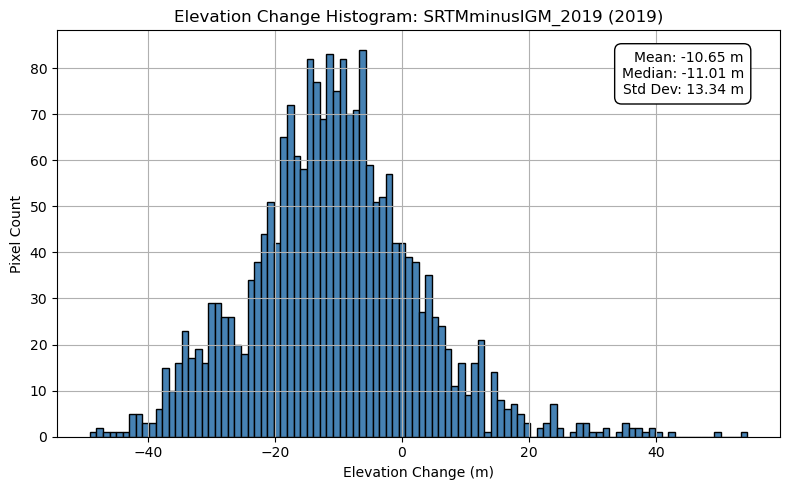


📂 Year: 2019
🔵 Raster: CBminusSRTM_2019


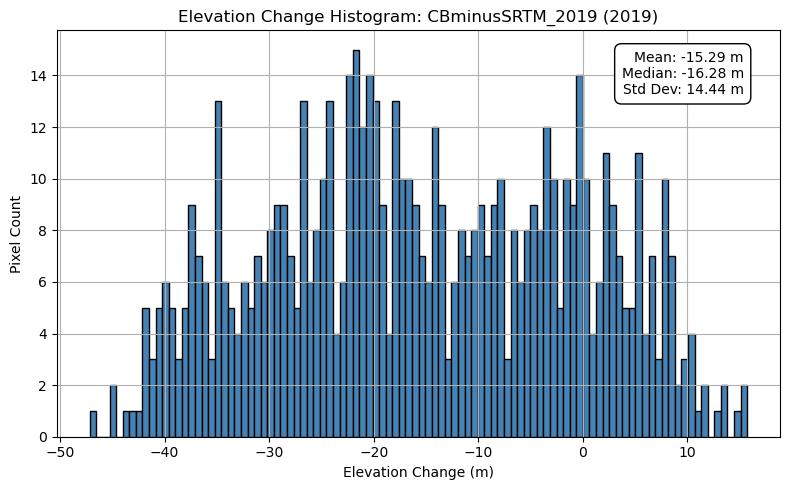


📂 Year: 2019
🔵 Raster: LTminusSRTM_2019


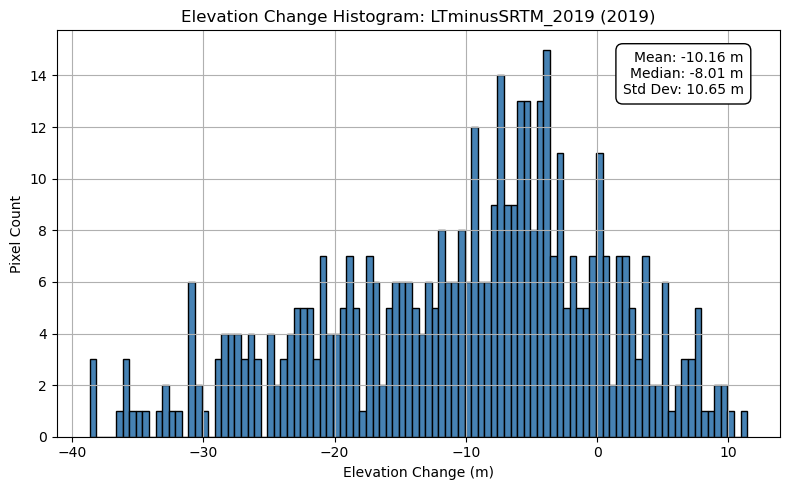


📂 Year: 2019
🔵 Raster: CBminusIGM_2019


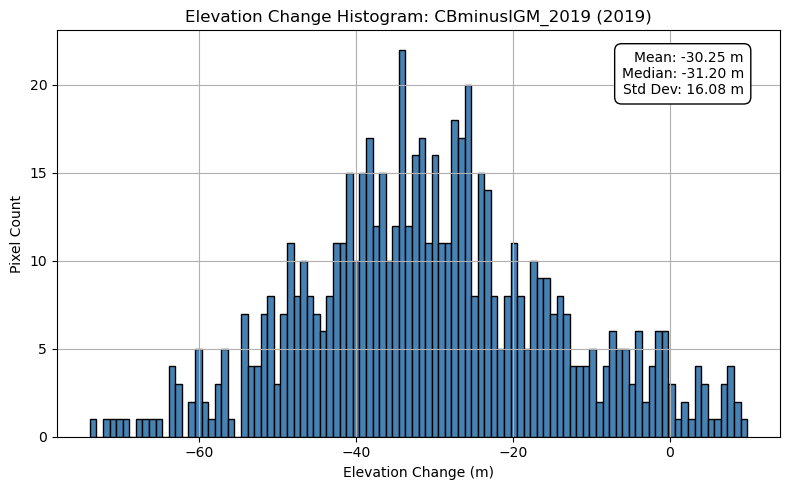


📂 Year: 2019
🔵 Raster: LTminusIGM_2019


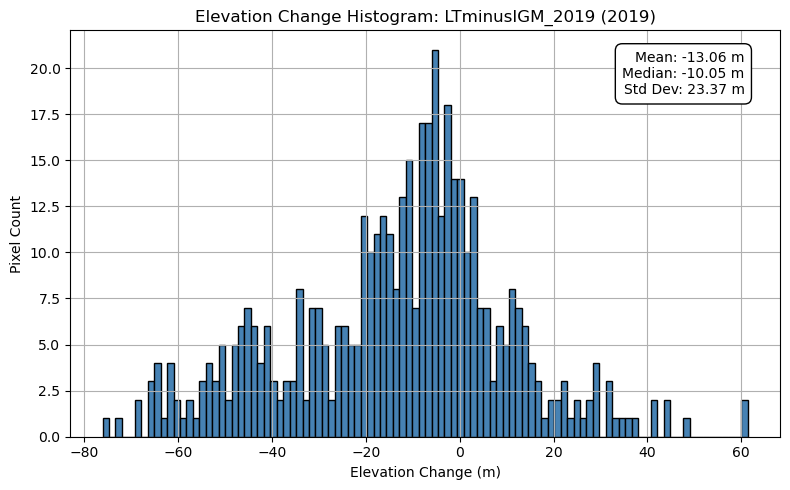

In [9]:
# ----------------------------
# Paths to glacier outlines
# ----------------------------
glacier_outlines = { "2000": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp", "2019": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp" }

# ----------------------------
# Paths to elevation difference rasters
# ----------------------------
raster_paths = {
    "SRTMminusIGM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2000_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2000/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2000/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2000_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2000_updated/LasTermas_DEMproject_clp_diff.tif",
    "SRTMminusIGM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2019_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2019/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2019/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2019_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2019_updated/LasTermas_DEMproject_clp_diff.tif"
}

# ----------------------------
# Function to extract valid elevation change pixels
# ----------------------------
def extract_valid_pixels(raster_path, glacier_polygon):
    if glacier_polygon is None:
        return np.array([])  # Skip None geometries

    try:
        with rasterio.open(raster_path) as src:
            out_image, _ = mask(src, [mapping(glacier_polygon)], crop=True)
            out_image = out_image[0]

            # Replace extreme values with NaN
            out_image = np.where((out_image >= 1e38) | (out_image <= -9999), np.nan, out_image)
            return out_image.flatten()
    except ValueError as e:
        if "Input shapes do not overlap raster" in str(e):
            return np.array([])  # No overlap: return empty
        else:
            raise e
    except Exception as e:
        print(f"❌ Unexpected error during masking: {e}")
        return np.array([])

# ----------------------------
# Process rasters
# ----------------------------
output_dir = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"
os.makedirs(output_dir, exist_ok=True)

for raster_name, raster_path in raster_paths.items():
    # Automatically select the correct glacier shapefile based on year
    if "_2000" in raster_name:
        year = "2000"
    elif "_2019" in raster_name:
        year = "2019"
    else:
        print(f"❌ Could not determine year from raster name: {raster_name}")
        continue

    print(f"\n📂 Year: {year}\n🔵 Raster: {raster_name}")

    gdf = gpd.read_file(glacier_outlines[year])
    all_pixels = []

    for _, row in gdf.iterrows():
        if row.geometry is None or row.geometry.is_empty:
            continue  # Skip missing or empty geometries

        pixels = extract_valid_pixels(raster_path, row.geometry)
        valid_pixels = pixels[~np.isnan(pixels)]
        all_pixels.extend(valid_pixels)

    all_pixels = np.array(all_pixels)

    if all_pixels.size == 0:
        print("⚠️ No valid pixels found in raster-glacier intersection. Skipping.")
        continue

    # Save pixels to CSV
    output_csv = os.path.join(output_dir, f"{raster_name}_{year}_pixels.csv")
    pd.DataFrame(all_pixels, columns=["dh"]).to_csv(output_csv, index=False)

    # Calculate summary statistics
    mean_val = np.mean(all_pixels)
    median_val = np.median(all_pixels)
    std_val = np.std(all_pixels)

    # Plot histogram
    plt.figure(figsize=(8, 5))
    plt.hist(all_pixels, bins=100, color='steelblue', edgecolor='black')
    plt.title(f"Elevation Change Histogram: {raster_name} ({year})")
    plt.xlabel("Elevation Change (m)")
    plt.ylabel("Pixel Count")
    plt.grid(True)

    # Add text box with stats
    stats_text = f"Mean: {mean_val:.2f} m\nMedian: {median_val:.2f} m\nStd Dev: {std_val:.2f} m"
    plt.text(0.95, 0.95, stats_text, ha='right', va='top', transform=plt.gca().transAxes,
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

    plt.tight_layout()
    plt.show()


In [10]:
# Folder containing all *_pixels.csv files
pixel_dir = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"
output_csv = os.path.join(pixel_dir, "t_test_results_2000_vs_2019.csv")

# List all CSVs
all_files = [f for f in os.listdir(pixel_dir) if f.endswith('_pixels.csv')]

# Parse raster base names and years from filenames
data_dict = {}
for f in all_files:
    parts = f.replace('.csv','').split('_')
    # Example: CBminusIGM_2000_2000_pixels.csv -> raster_base=CBminusIGM, outline_year=2000
    raster_base = parts[0]
    outline_year = parts[1]
    csv_path = os.path.join(pixel_dir, f)

    if raster_base not in data_dict:
        data_dict[raster_base] = {}
    data_dict[raster_base][outline_year] = csv_path

# Perform t-tests
results = []
for raster_base, files in data_dict.items():
    if '2000' in files and '2019' in files:
        df_2000 = pd.read_csv(files['2000'])['dh'].dropna()
        df_2019 = pd.read_csv(files['2019'])['dh'].dropna()

        t_stat, p_value = stats.ttest_ind(df_2000, df_2019, equal_var=False)
        cohen_d = (df_2000.mean() - df_2019.mean()) / np.sqrt((df_2000.std()**2 + df_2019.std()**2)/2)

        results.append({
            'Raster_base': raster_base,
            'n_2000': len(df_2000),
            'n_2019': len(df_2019),
            'Mean_2000': df_2000.mean(),
            'Mean_2019': df_2019.mean(),
            'SD_2000': df_2000.std(),
            'SD_2019': df_2019.std(),
            't_stat': t_stat,
            'p_value': p_value,
            'cohen_d': cohen_d
        })
    else:
        print(f"⚠️ Missing 2000 or 2019 data for {raster_base}, skipping t-test.")

# Save results
results_df = pd.DataFrame(results)
results_df.to_csv(output_csv, index=False)
print(f"📊 T-Test Results saved to: {output_csv}")
results_df


📊 T-Test Results saved to: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats/t_test_results_2000_vs_2019.csv


,Raster_base,n_2000,n_2019,Mean_2000,Mean_2019,SD_2000,SD_2019,t_stat,p_value,cohen_d
0,SRTMminusIGM,3224,2119,-10.895385,-10.653019,14.296125,13.340514,-0.631323,0.527859,-0.017529
1,LTminusIGM,649,460,-10.606552,-13.064282,20.124010,23.395252,1.824869,0.068355,0.112631
2,CBminusSRTM,764,656,-17.023925,-15.285480,13.824094,14.452450,-2.305577,0.021284,-0.122930
3,CBminusIGM,764,656,-33.433475,-30.247119,17.248119,16.093014,-3.598188,0.000332,-0.191022
4,LTminusSRTM,649,460,-9.077372,-10.160939,10.536143,10.656928,1.676096,0.094038,0.102255


In [11]:
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Folder containing all *_pixels.csv files
pixel_dir = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"
output_csv = os.path.join(pixel_dir, "t_test_results_2000_vs_2019.csv")
output_png = os.path.join(pixel_dir, "t_test_results_2000_vs_2019.png")

# List all CSVs
all_files = [f for f in os.listdir(pixel_dir) if f.endswith('_pixels.csv')]

# Parse raster base names and years from filenames
data_dict = {}
for f in all_files:
    parts = f.replace('.csv','').split('_')
    raster_base = parts[0]
    outline_year = parts[1]
    csv_path = os.path.join(pixel_dir, f)

    if raster_base not in data_dict:
        data_dict[raster_base] = {}
    data_dict[raster_base][outline_year] = csv_path

# Perform t-tests
results = []
for raster_base, files in data_dict.items():
    if '2000' in files and '2019' in files:
        df_2000 = pd.read_csv(files['2000'])['dh'].dropna()
        df_2019 = pd.read_csv(files['2019'])['dh'].dropna()

        t_stat, p_value = stats.ttest_ind(df_2000, df_2019, equal_var=False)
        cohen_d = (df_2000.mean() - df_2019.mean()) / np.sqrt((df_2000.std()**2 + df_2019.std()**2)/2)

        results.append({
            'Raster_base': raster_base,
            'Number_of_Pixels_2000': len(df_2000),
            'Number_of_Pixels_2019': len(df_2019),
            'Mean_dH_2000': df_2000.mean(),
            'Mean_dH_2019': df_2019.mean(),
            'SD_2000': df_2000.std(),
            'SD_2019': df_2019.std(),
            't_stat': t_stat,
            'p_value': p_value,
            'cohen_d': cohen_d
        })
    else:
        print(f"⚠️ Missing 2000 or 2019 data for {raster_base}, skipping t-test.")

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Save as CSV
results_df.to_csv(output_csv, index=False)
print(f"📊 T-Test Results saved to: {output_csv}")

# -------------------------------
# Save table as PNG
# -------------------------------
# Round numeric columns only
results_rounded = results_df.copy()
numeric_cols = results_rounded.select_dtypes(include='number').columns
results_rounded[numeric_cols] = results_rounded[numeric_cols].round(3)

fig, ax = plt.subplots(figsize=(12, max(2, len(results_df)*0.5)))  # Adjust height
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=results_rounded.values,
                 colLabels=results_rounded.columns,
                 cellLoc='center',
                 loc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(results_rounded.columns))))

plt.tight_layout()
plt.savefig(output_png, dpi=300)
plt.close()
print(f"🖼️ T-Test table saved as PNG: {output_png}")

desktop_path = os.path.expanduser("~/Desktop/t_test_results_2000_vs_2019.png")
shutil.copy(output_png, desktop_path)
print(f"✅ PNG copied to Desktop: {desktop_path}")


📊 T-Test Results saved to: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats/t_test_results_2000_vs_2019.csv
🖼️ T-Test table saved as PNG: /Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats/t_test_results_2000_vs_2019.png
✅ PNG copied to Desktop: /Users/milliespencer/Desktop/t_test_results_2000_vs_2019.png


# Step 3: Geospatial analysis
## is glacier elevation loss for a 30x30 pixel related to its geographic attributes? 
### E.g. do steeper pixels have a higher or lower elevation loss than flatter pixels? What about pixels at higher/lower elevations? North vs East aspect? 

Here we: 
- Load each raster’s elevation change pixels (dH) from the CSVs you saved in Step 2
- Extract the pixels’ elevation, slope, and aspect from the SRTM DEM raster (for consistency just using this raster)
- Combine dH and geographic variables per pixel
- Perform correlation analysis between dH and elevation, slope, and aspect
- Plot the relationships with regression lines and reports correlation coefficients and p-values

Loading DEM and calculating slope/aspect...
Done with DEM preprocessing.

Processing SRTMminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 3224, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = -0.103, r² = 0.011, p = 5.38e-09


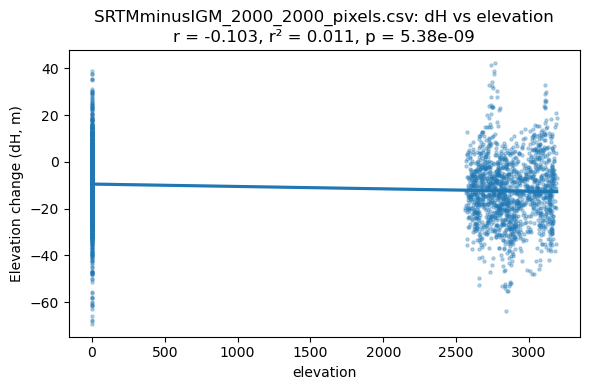

dH vs slope | r = -0.051, r² = 0.003, p = 0.00397


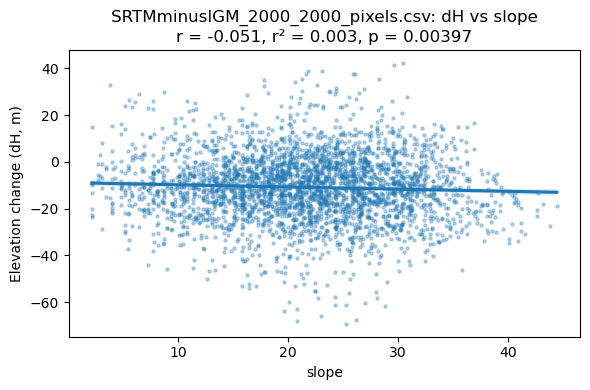

dH vs aspect | r = -0.004, r² = 0.000, p = 0.817


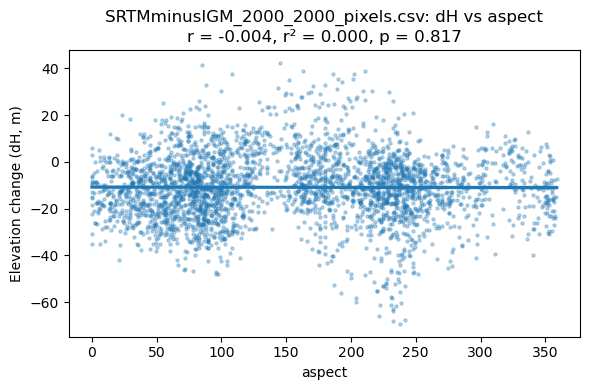

Skipping SRTMminusIGM_2019_2000_pixels.csv because years do not match or are ambiguous: ['2019', '2000']

Processing SRTMminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 2119, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.125, r² = 0.016, p = 8.51e-09


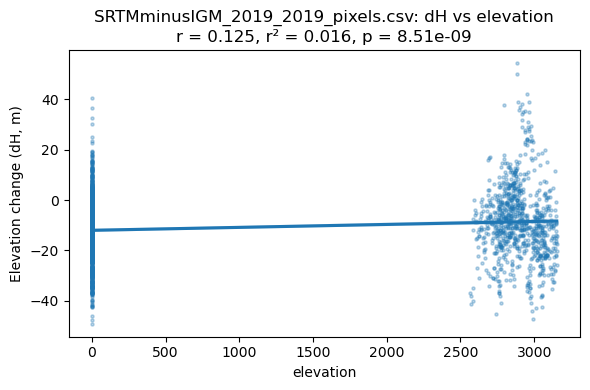

dH vs slope | r = 0.018, r² = 0.000, p = 0.416


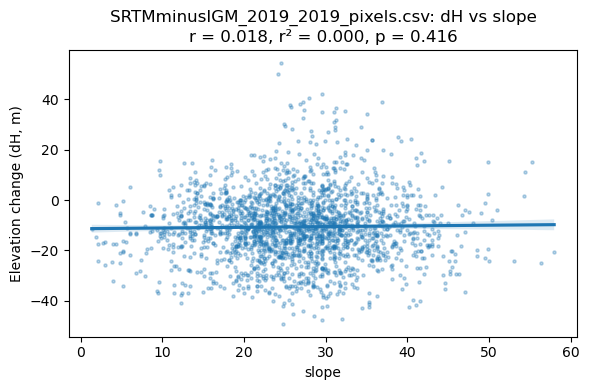

dH vs aspect | r = -0.024, r² = 0.001, p = 0.265


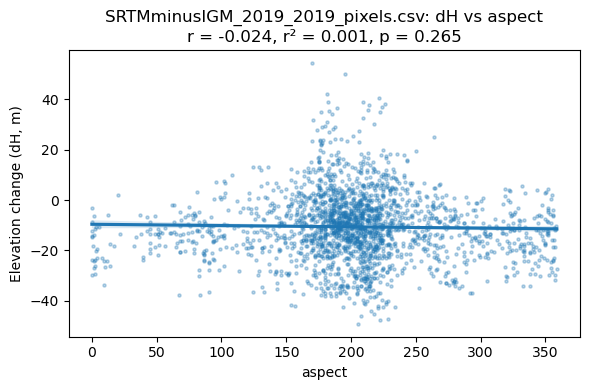


Processing LTminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 649, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.008, r² = 0.000, p = 0.842


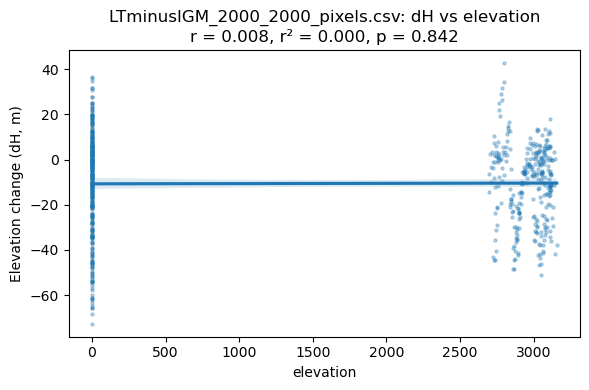

dH vs slope | r = -0.070, r² = 0.005, p = 0.0752


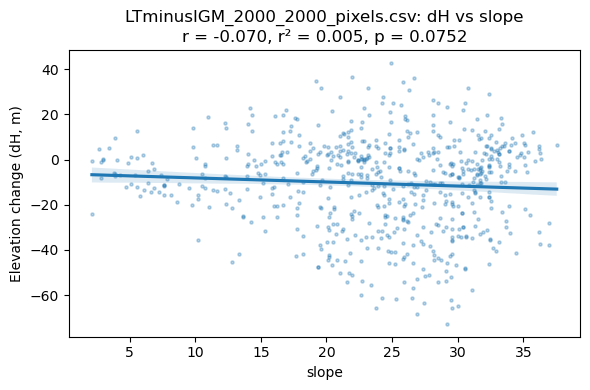

dH vs aspect | r = -0.103, r² = 0.011, p = 0.00892


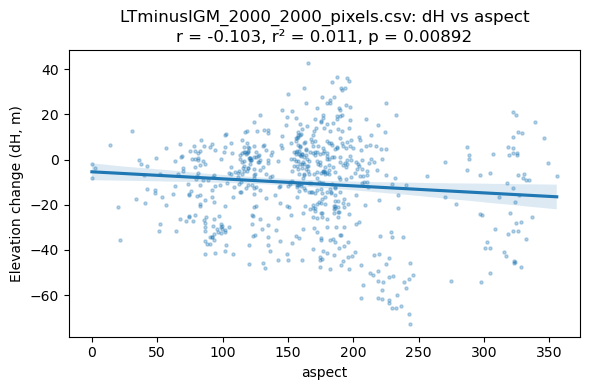


Processing LTminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 460, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.046, r² = 0.002, p = 0.327


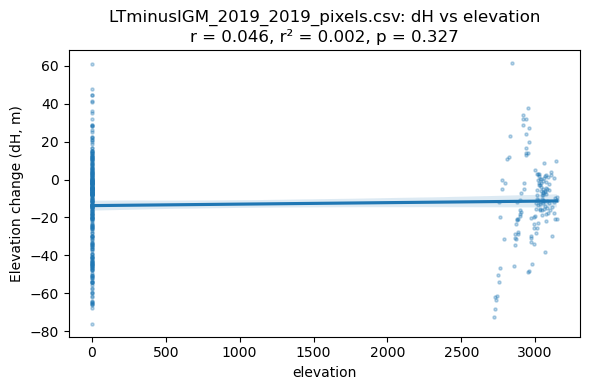

dH vs slope | r = 0.054, r² = 0.003, p = 0.25


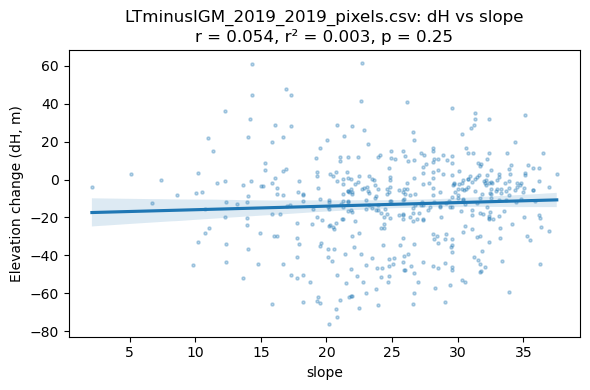

dH vs aspect | r = 0.225, r² = 0.051, p = 1.12e-06


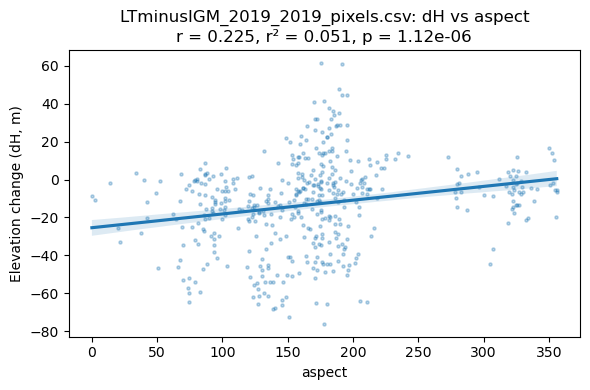

Skipping t_test_results.csv because years do not match or are ambiguous: []

Processing CBminusSRTM_2019_2019_pixels.csv for year 2019
dH pixels: 656, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.175, r² = 0.031, p = 6.52e-06


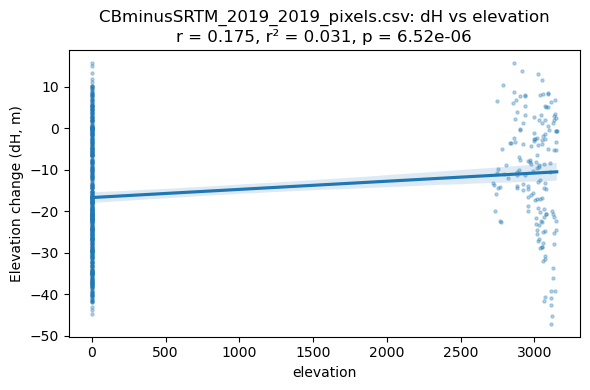

dH vs slope | r = 0.097, r² = 0.009, p = 0.0128


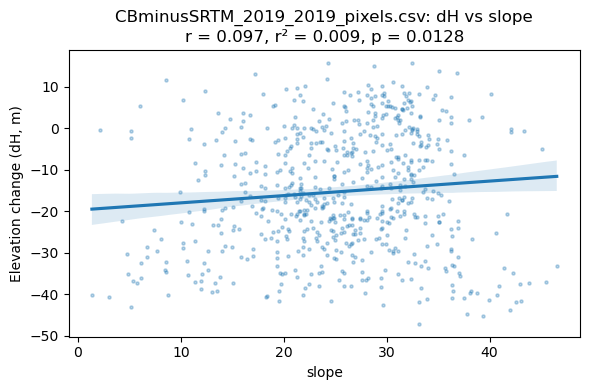

dH vs aspect | r = -0.084, r² = 0.007, p = 0.0317


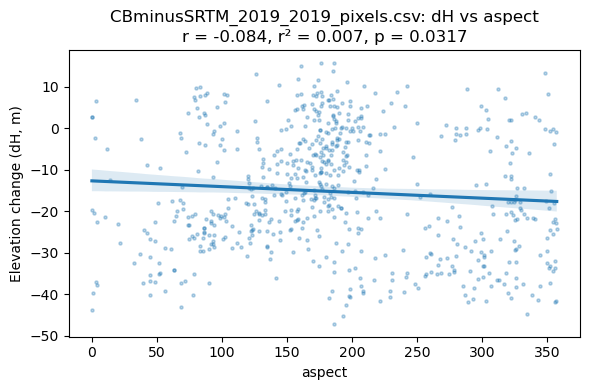

Skipping t_test_results_2000_vs_2019.csv because years do not match or are ambiguous: ['2000']

Processing CBminusSRTM_2000_2000_pixels.csv for year 2000
dH pixels: 764, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.049, r² = 0.002, p = 0.177


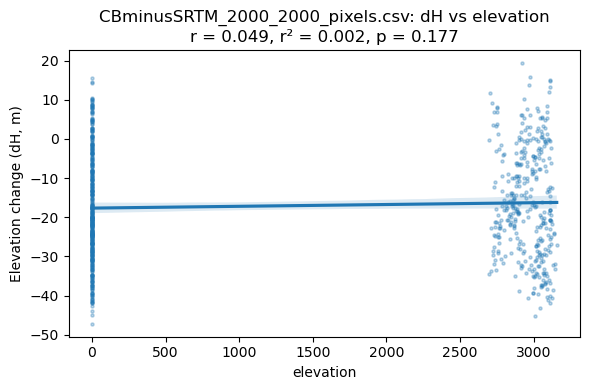

dH vs slope | r = 0.146, r² = 0.021, p = 4.98e-05


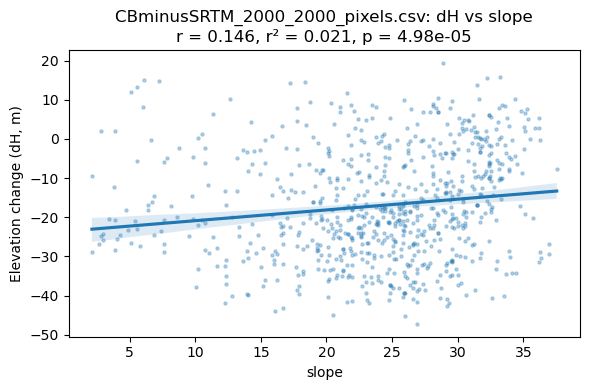

dH vs aspect | r = -0.088, r² = 0.008, p = 0.0146


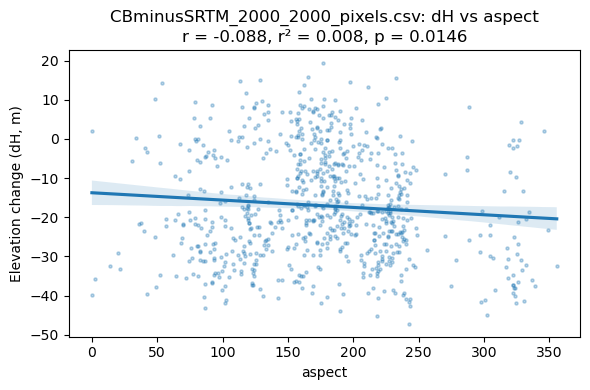


Processing CBminusIGM_2019_2019_pixels.csv for year 2019
dH pixels: 656, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.155, r² = 0.024, p = 6.42e-05


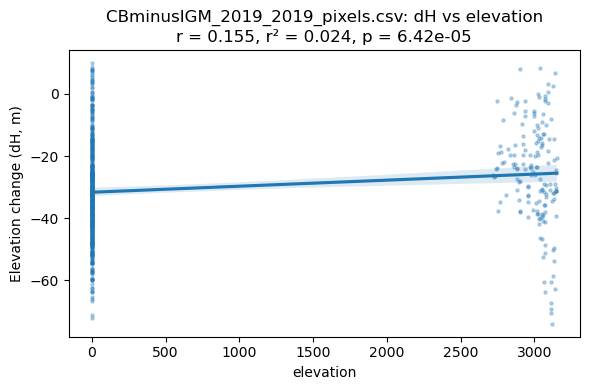

dH vs slope | r = 0.075, r² = 0.006, p = 0.0559


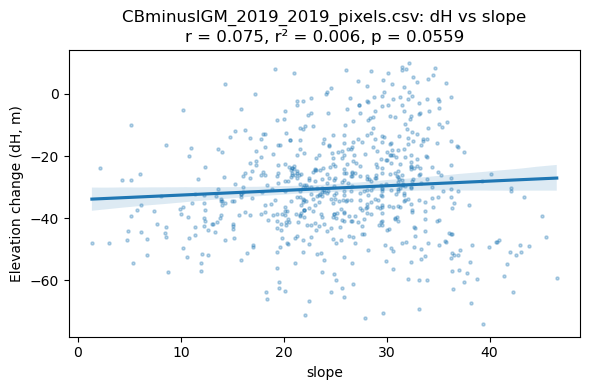

dH vs aspect | r = -0.200, r² = 0.040, p = 2.48e-07


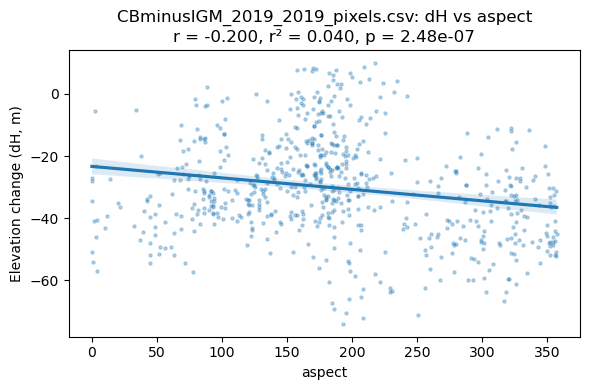

Skipping All_dH_pixels_combined.csv because years do not match or are ambiguous: []

Processing LTminusSRTM_2000_2000_pixels.csv for year 2000
dH pixels: 649, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.230, r² = 0.053, p = 2.93e-09


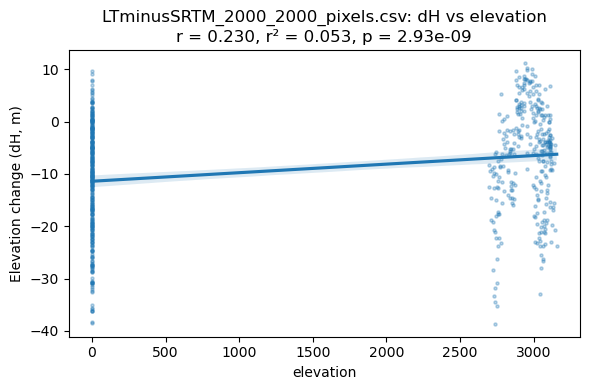

dH vs slope | r = 0.189, r² = 0.036, p = 1.21e-06


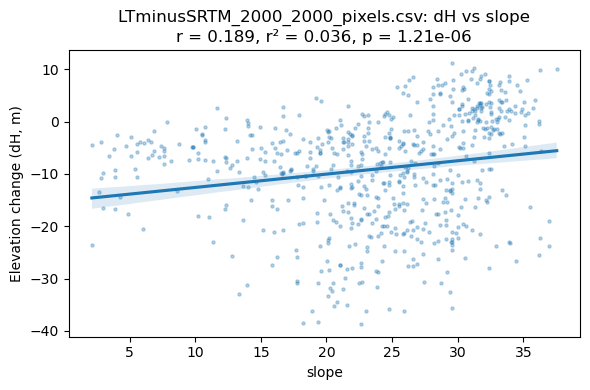

dH vs aspect | r = -0.043, r² = 0.002, p = 0.271


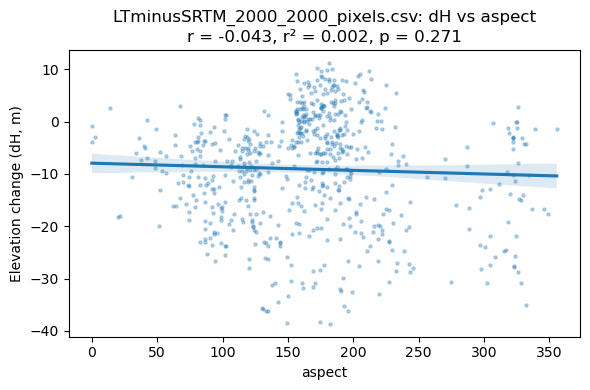


Processing LTminusSRTM_2019_2019_pixels.csv for year 2019
dH pixels: 460, elev: 6467, slope: 6467, aspect: 6467
dH vs elevation | r = 0.032, r² = 0.001, p = 0.499


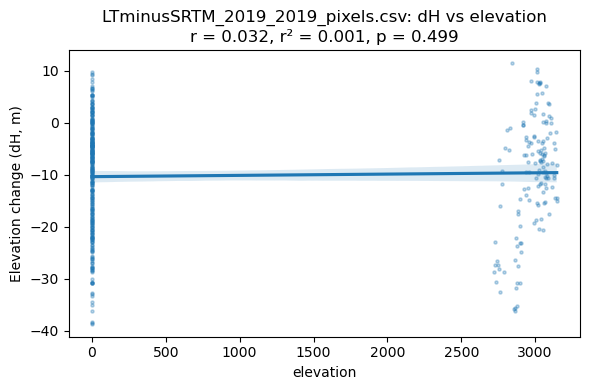

dH vs slope | r = 0.247, r² = 0.061, p = 8.44e-08


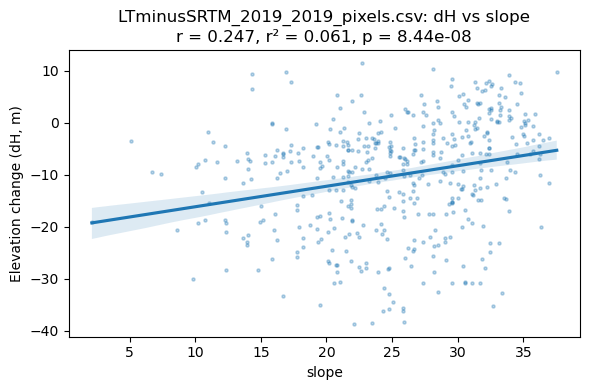

dH vs aspect | r = 0.173, r² = 0.030, p = 0.000194


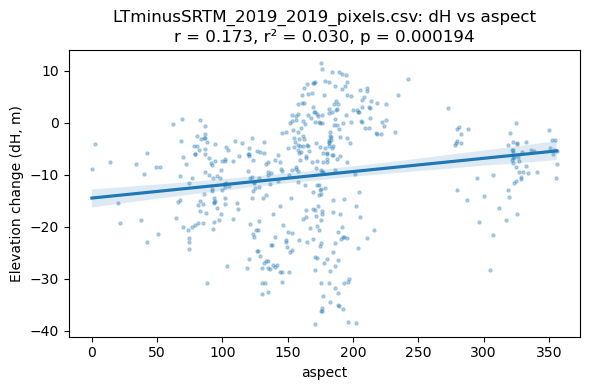


Processing CBminusIGM_2000_2000_pixels.csv for year 2000
dH pixels: 764, elev: 8311, slope: 8311, aspect: 8311
dH vs elevation | r = 0.104, r² = 0.011, p = 0.00394


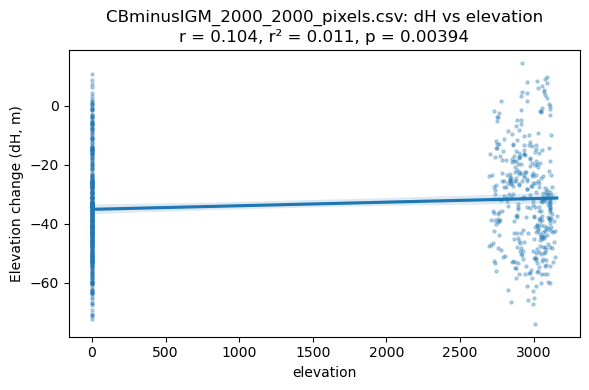

dH vs slope | r = 0.154, r² = 0.024, p = 1.83e-05


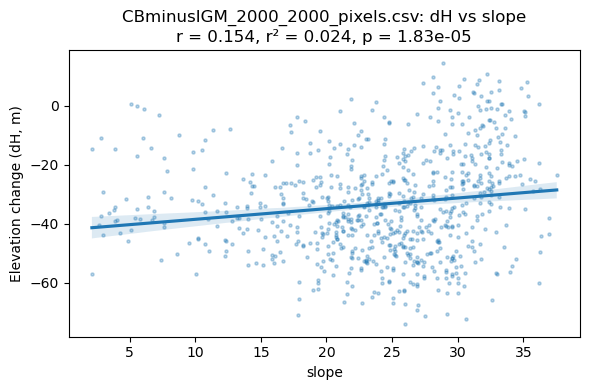

dH vs aspect | r = -0.165, r² = 0.027, p = 4.37e-06


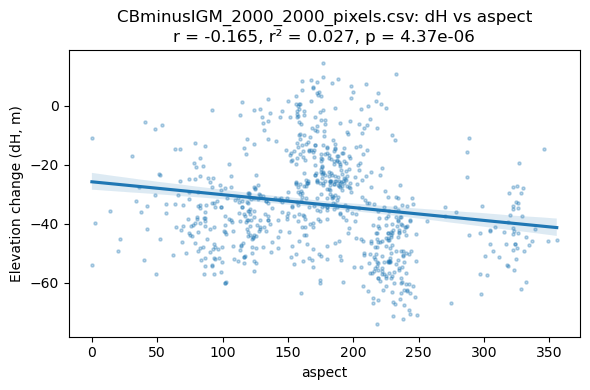

In [13]:
# Folder where Step 1 saved dH CSV files
dH_csv_folder = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/Nevados_dH_Stats/pixel_stats"

# Path to the true elevation DEM raster (SRTM)
dem_path = "/Users/milliespencer/Desktop/70_Years_MB_Nevados/NEWDEMs_to_coregister_nevados/SRTM_DEMprojected.tif"

# Paths to glacier shapefiles by year
glacier_shapefiles = {
    "2000": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2000/Nevados_polygons_DGA2000.shp",
    "2019": "/Users/milliespencer/Glacier-DEM-coregistration-and-MB/example_data_Nevados/Nevados_glacier_shapefiles/Nevados_shapefile_DGA2019/Nevados_polygons_DGA2019.shp"
}

def calculate_slope_aspect(dem_array, dem_transform):
    xres = dem_transform[0]
    yres = -dem_transform[4]

    dy, dx = np.gradient(dem_array, yres, xres)
    slope_rad = np.arctan(np.sqrt(dx**2 + dy**2))
    slope_deg = np.degrees(slope_rad)

    aspect_rad = np.arctan2(-dx, dy)
    aspect_deg = np.degrees(aspect_rad)
    aspect_deg = np.where(aspect_deg < 0, 360 + aspect_deg, aspect_deg)

    return slope_deg, aspect_deg

print("Loading DEM and calculating slope/aspect...")
with rasterio.open(dem_path) as dem_src:
    dem_arr = dem_src.read(1)
    dem_arr = np.where((dem_arr >= 1e38) | (dem_arr <= -9999), np.nan, dem_arr)
    dem_transform = dem_src.transform
    slope_arr, aspect_arr = calculate_slope_aspect(dem_arr, dem_transform)
print("Done with DEM preprocessing.")

# Loop over each dH CSV file from Step 1
for filename in os.listdir(dH_csv_folder):
    if not filename.endswith(".csv"):
        continue

    parts = filename.split('_')
    years_in_name = [p for p in parts if p in ["2000", "2019"]]

    if len(years_in_name) != 2 or years_in_name[0] != years_in_name[1]:
        print(f"Skipping {filename} because years do not match or are ambiguous: {years_in_name}")
        continue

    year = years_in_name[0]
    print(f"\nProcessing {filename} for year {year}")

    # Load glacier polygons for this year
    gdf = gpd.read_file(glacier_shapefiles[year])

    # Load dH values
    dH_df = pd.read_csv(os.path.join(dH_csv_folder, filename))
    dH_values = dH_df['dh'].values

    all_dem_elev = []
    all_dem_slope = []
    all_dem_aspect = []

    with rasterio.open(dem_path) as dem_src:
        for _, row in gdf.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue
            try:
                window_image, window_transform = mask(dem_src, [row.geometry], crop=True)
                window_elev = window_image[0]
                window_elev = np.where((window_elev >= 1e38) | (window_elev <= -9999), np.nan, window_elev)

                rows, cols = np.where(~np.isnan(window_elev))

                global_rows = rows + int((window_transform.f - dem_transform.f) / dem_transform.e)
                global_cols = cols + int((window_transform.c - dem_transform.c) / dem_transform.a)

                elev_vals = window_elev[rows, cols]
                slope_vals = slope_arr[global_rows, global_cols]
                aspect_vals = aspect_arr[global_rows, global_cols]

                all_dem_elev.extend(elev_vals)
                all_dem_slope.extend(slope_vals)
                all_dem_aspect.extend(aspect_vals)

            except Exception as e:
                print(f"Error processing polygon: {e}")
                continue

    all_dem_elev = np.array(all_dem_elev)
    all_dem_slope = np.array(all_dem_slope)
    all_dem_aspect = np.array(all_dem_aspect)

    print(f"dH pixels: {len(dH_values)}, elev: {len(all_dem_elev)}, slope: {len(all_dem_slope)}, aspect: {len(all_dem_aspect)}")
    min_len = min(len(dH_values), len(all_dem_elev), len(all_dem_slope), len(all_dem_aspect))

    if min_len == 0:
        print(f"No valid combined data for {filename}, skipping.")
        continue

    dH_values = dH_values[:min_len]
    all_dem_elev = all_dem_elev[:min_len]
    all_dem_slope = all_dem_slope[:min_len]
    all_dem_aspect = all_dem_aspect[:min_len]

    df = pd.DataFrame({
        'dH': dH_values,
        'elevation': all_dem_elev,
        'slope': all_dem_slope,
        'aspect': all_dem_aspect
    }).dropna()

    if df.empty:
        print(f"No valid data after dropping NaNs for {filename}, skipping.")
        continue

    for var in ['elevation', 'slope', 'aspect']:
        r, p = pearsonr(df['dH'], df[var])
        r2 = r ** 2
        print(f"dH vs {var} | r = {r:.3f}, r² = {r2:.3f}, p = {p:.3g}")

        plt.figure(figsize=(6, 4))
        sns.regplot(x=var, y='dH', data=df, scatter_kws={'alpha': 0.3, 's': 5})
        plt.title(f"{filename}: dH vs {var}\nr = {r:.3f}, r² = {r2:.3f}, p = {p:.3g}")
        plt.xlabel(var)
        plt.ylabel("Elevation change (dH, m)")
        plt.tight_layout()
        plt.show()

Across the board small r2 values. Weak relationship between dH and geographic variables. Some predictive power, but low.

Elevation is the strongest topographic predictor of elevation change (dH), explaining up to ~29% of variance.

Slope shows weak positive effects, likely minor compared to elevation.

Aspect generally has negligible influence, with a few weak correlations.

Statistical significance (p-value) is often driven by large sample sizes rather than strong relationships. Effect size (r²) is more important for practical interpretation.

Patterns vary by glacier and year: some glaciers (CBminusIGM_2000) show strong elevation dependence, others (LTminusSRTM_2000) show almost no topographic influence.


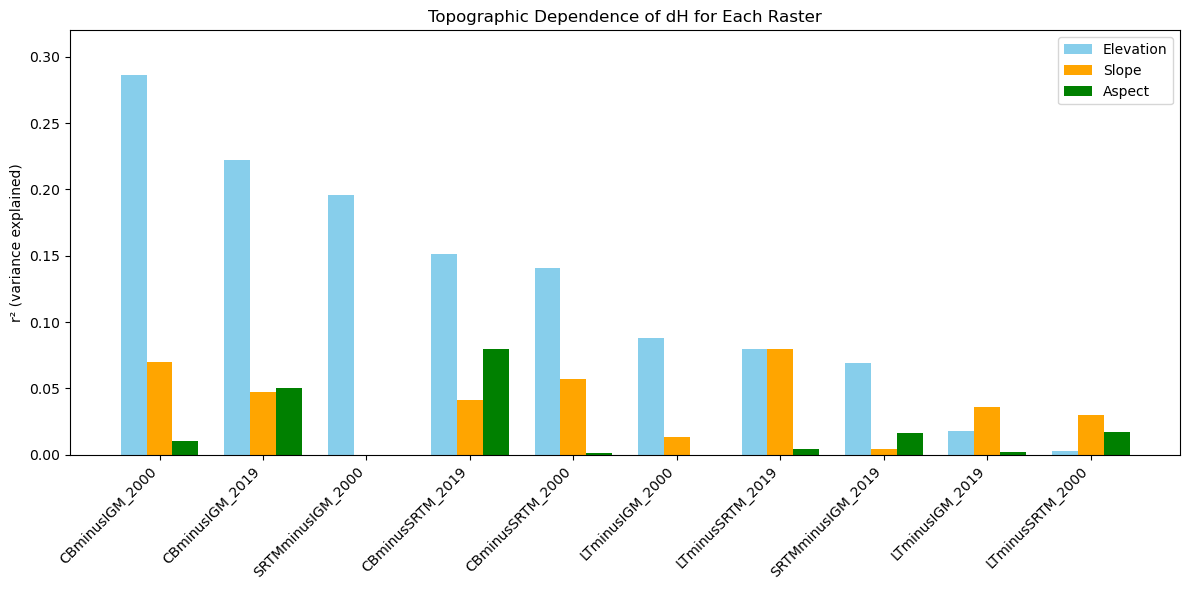

In [14]:
# Create a dataframe of r² values
data = {
    'Raster': [
        "CBminusIGM_2000", "SRTMminusIGM_2000", "CBminusIGM_2019", "CBminusSRTM_2019",
        "CBminusSRTM_2000", "LTminusIGM_2000", "SRTMminusIGM_2019", "LTminusSRTM_2019",
        "LTminusSRTM_2000", "LTminusIGM_2019"
    ],
    'Elevation_r2': [0.286, 0.196, 0.222, 0.151, 0.141, 0.088, 0.069, 0.080, 0.003, 0.018],
    'Slope_r2': [0.070, 0.000, 0.047, 0.041, 0.057, 0.013, 0.004, 0.080, 0.030, 0.036],
    'Aspect_r2': [0.010, 0.000, 0.050, 0.080, 0.001, 0.000, 0.016, 0.004, 0.017, 0.002]
}

df = pd.DataFrame(data)

# Sort by elevation for plotting (optional, makes bars easier to read)
df_sorted = df.sort_values('Elevation_r2', ascending=False)

# Plot
x = np.arange(len(df_sorted))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, df_sorted['Elevation_r2'], width, label='Elevation', color='skyblue')
ax.bar(x, df_sorted['Slope_r2'], width, label='Slope', color='orange')
ax.bar(x + width, df_sorted['Aspect_r2'], width, label='Aspect', color='green')

ax.set_xticks(x)
ax.set_xticklabels(df_sorted['Raster'], rotation=45, ha='right')
ax.set_ylabel('r² (variance explained)')
ax.set_title('Topographic Dependence of dH for Each Raster')
ax.legend()
ax.set_ylim(0, 0.32)

plt.tight_layout()
plt.show()


## SPATIAL AUTOCORRELATION ANALYSIS: are nearer pixels similar in dH value? 


Analyzing SRTMminusIGM_2000
Data shape: 254 rows x 233 cols
Global Moran’s I: 0.7768, p-value: 0.0010


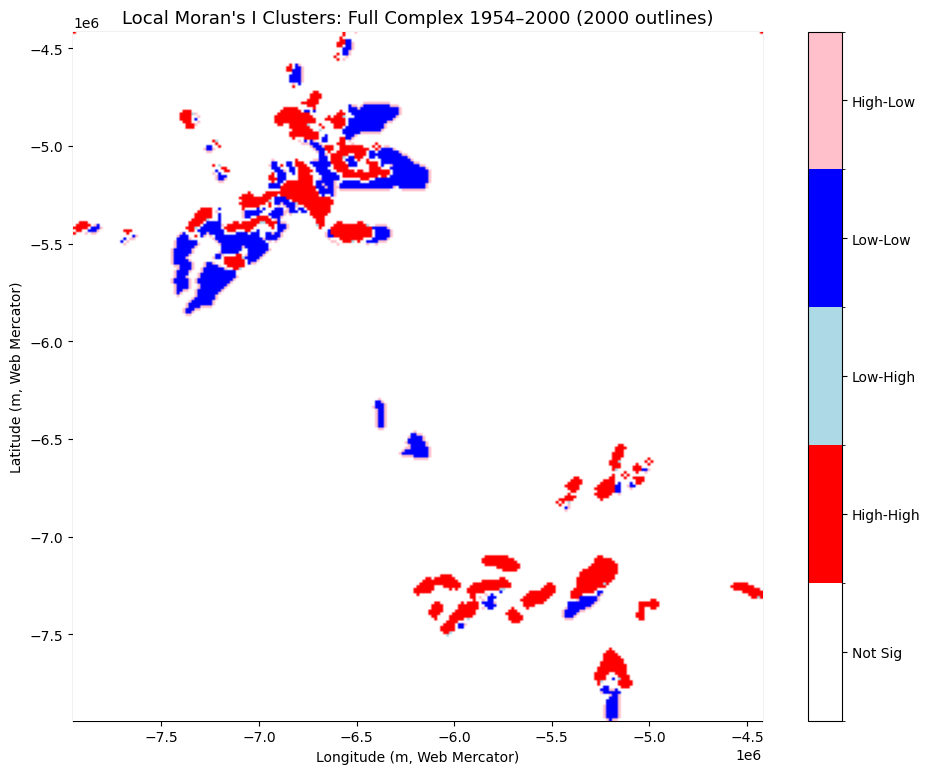


Analyzing CBminusSRTM_2000
Data shape: 46 rows x 40 cols
Global Moran’s I: 0.8023, p-value: 0.0010


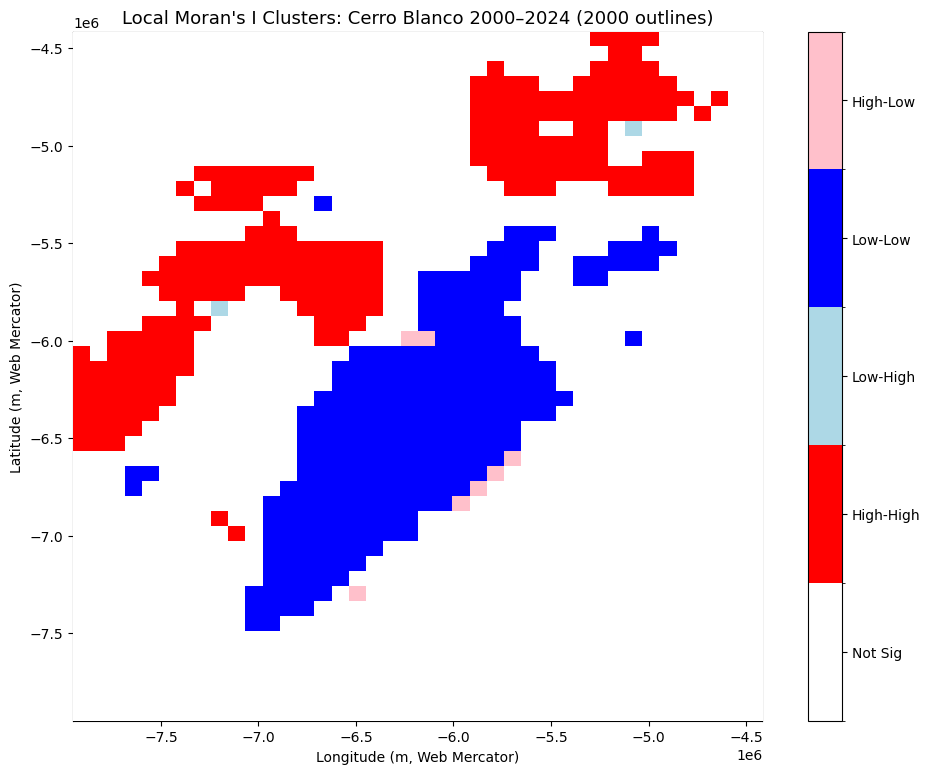


Analyzing LTminusSRTM_2000
Data shape: 60 rows x 81 cols
Global Moran’s I: 0.8234, p-value: 0.0010


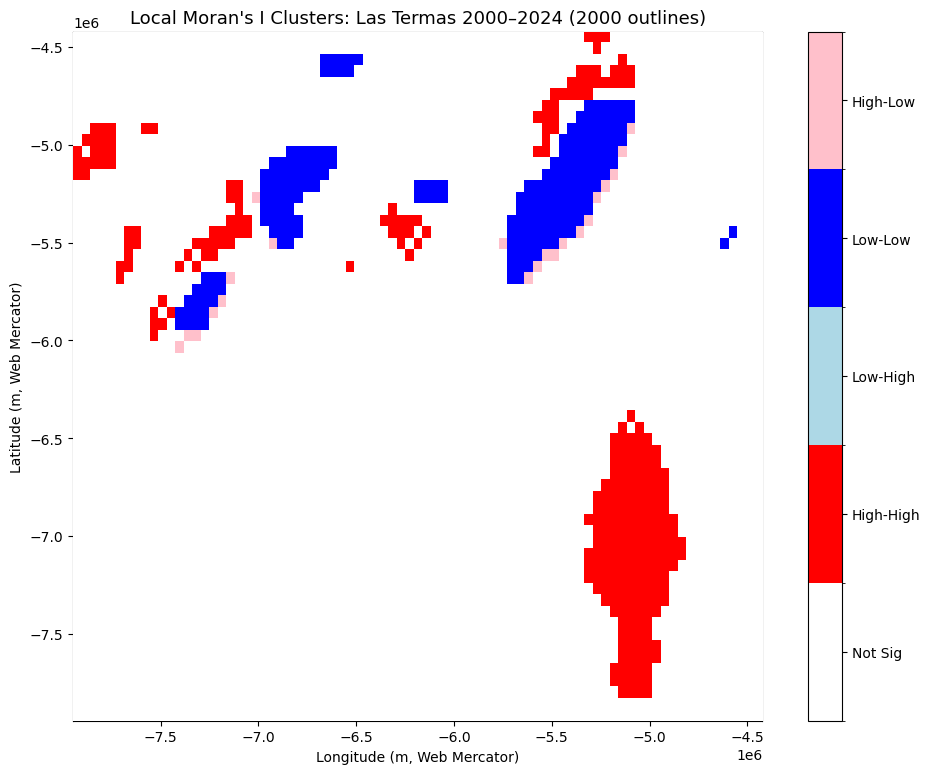


Analyzing CBminusIGM_2000
Data shape: 46 rows x 40 cols
Global Moran’s I: 0.8065, p-value: 0.0010


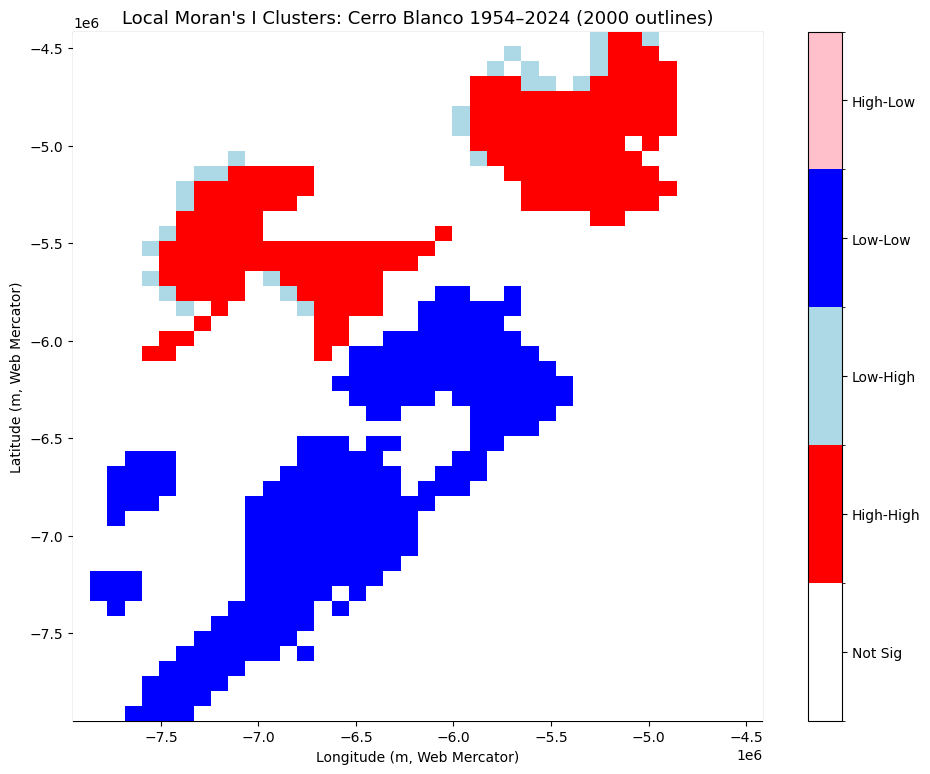


Analyzing LTminusIGM_2000
Data shape: 60 rows x 81 cols
Global Moran’s I: 0.7865, p-value: 0.0010


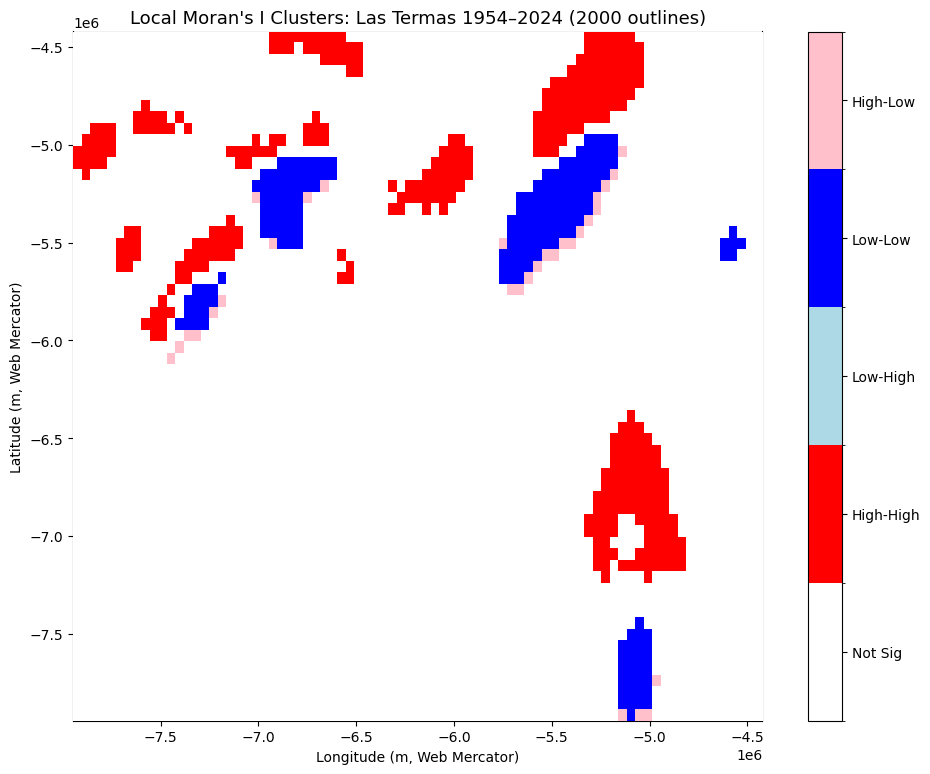


Analyzing SRTMminusIGM_2019
Data shape: 252 rows x 232 cols
Global Moran’s I: 0.6891, p-value: 0.0010


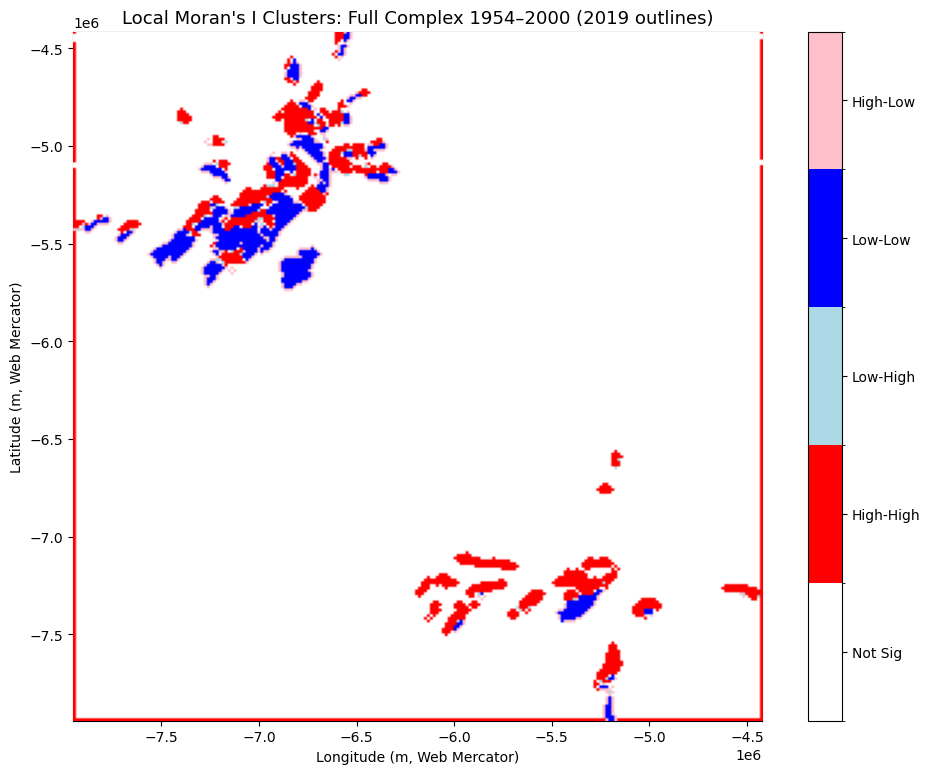


Analyzing CBminusSRTM_2019
Data shape: 37 rows x 46 cols
Global Moran’s I: 0.7894, p-value: 0.0010


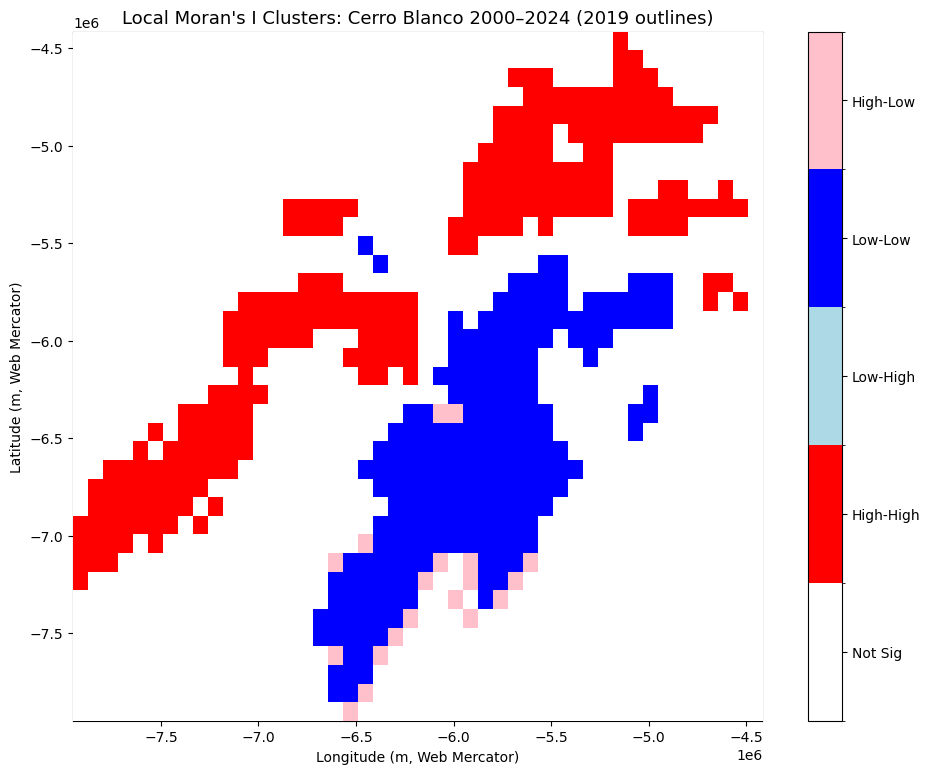


Analyzing LTminusSRTM_2019
Data shape: 61 rows x 81 cols
Global Moran’s I: 0.7707, p-value: 0.0010


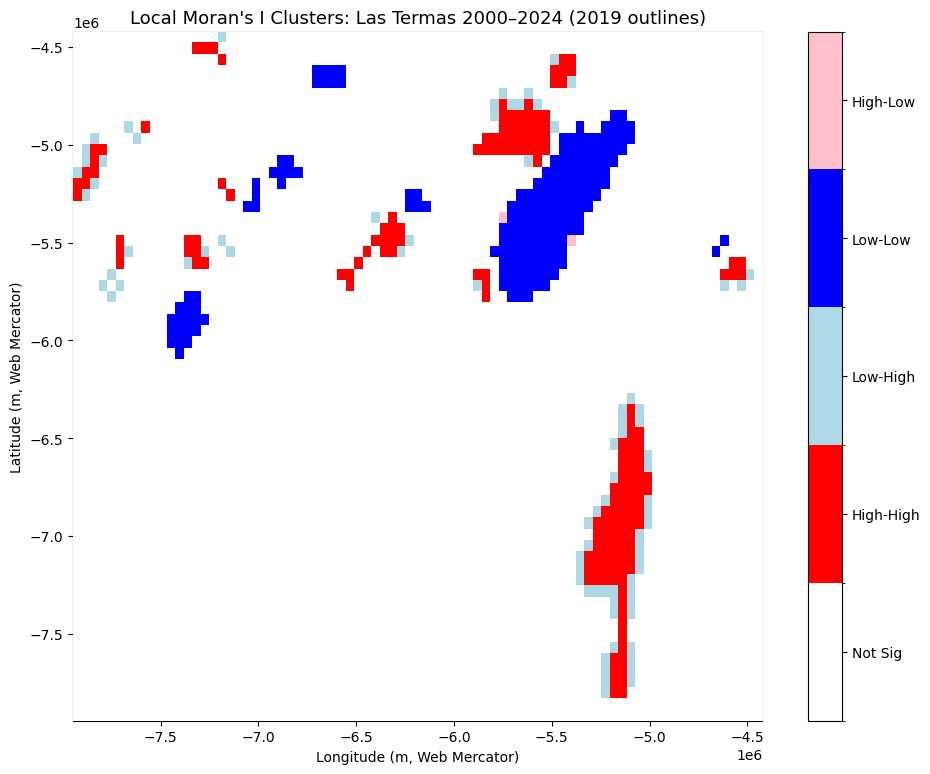


Analyzing CBminusIGM_2019
Data shape: 37 rows x 46 cols
Global Moran’s I: 0.7726, p-value: 0.0010


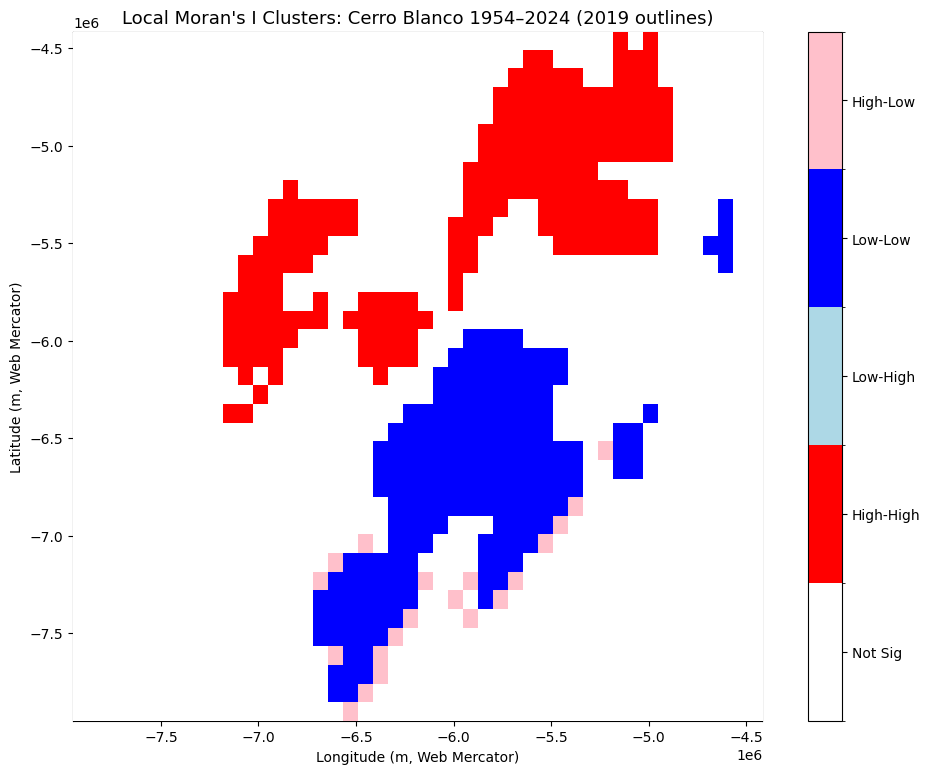


Analyzing LTminusIGM_2019
Data shape: 61 rows x 81 cols
Global Moran’s I: 0.7522, p-value: 0.0010


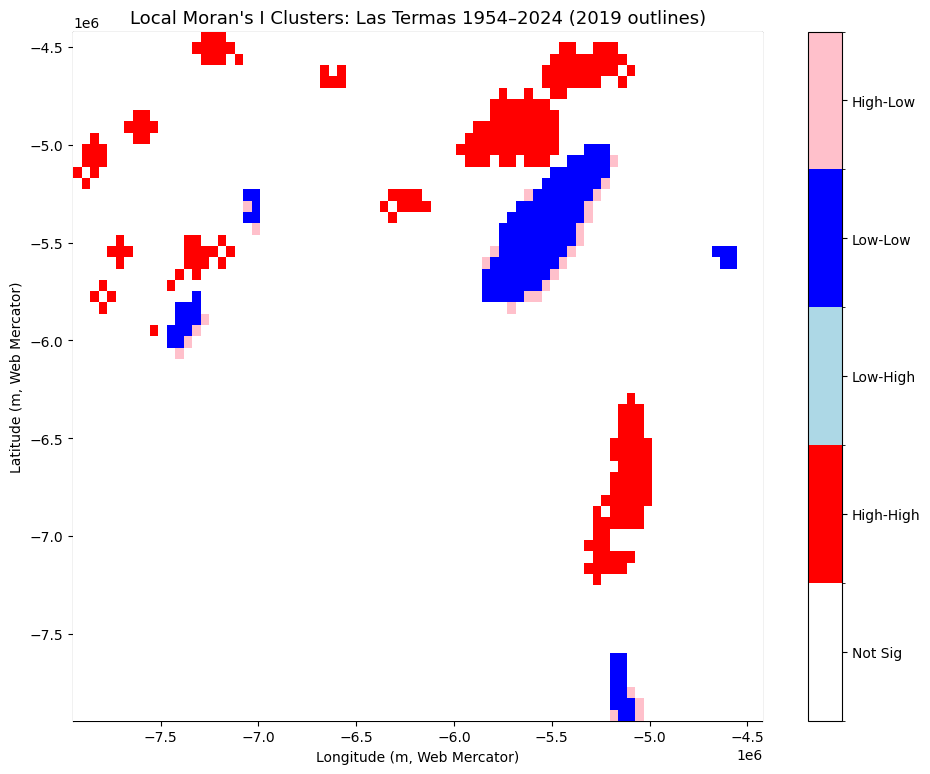

In [16]:
# ============================================================
# Local Moran’s I Cluster Analysis for Elevation Change Rasters
# ============================================================

# ---- Imports ----
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from esda.moran import Moran, Moran_Local
from libpysal.weights import lat2W
from rasterio.warp import transform_bounds
from rasterio.windows import Window
import contextily as ctx


# ----------------------------
# Paths to elevation difference rasters
# ----------------------------
raster_paths = {
    "SRTMminusIGM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2000_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2000/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2000/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2000_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2000": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2000_updated/LasTermas_DEMproject_clp_diff.tif",
    "SRTMminusIGM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2019_updated/SRTM_projected_raste_clp_diff.tif",
    "CBminusSRTM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2019/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusSRTM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseSRTM_poly2019/LasTermas_DEMproject_clp_diff.tif",
    "CBminusIGM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2019_updated/CerroBlanco_DEMproje_clp_diff.tif",
    "LTminusIGM_2019": "/Users/milliespencer/Desktop/70_Years_MB_Nevados/dems_20250721_updated/output_data_baseIGM_poly2019_updated/LasTermas_DEMproject_clp_diff.tif"
}


# ----------------------------
# Custom titles for figures
# ----------------------------
title_map = {
    # ---- 2000 outlines ----
    "SRTMminusIGM_2000": "Full Complex 1954–2000 (2000 outlines)",
    "CBminusIGM_2000": "Cerro Blanco 1954–2024 (2000 outlines)",
    "LTminusIGM_2000": "Las Termas 1954–2024 (2000 outlines)",
    "CBminusSRTM_2000": "Cerro Blanco 2000–2024 (2000 outlines)",
    "LTminusSRTM_2000": "Las Termas 2000–2024 (2000 outlines)",

    # ---- 2019 outlines ----
    "SRTMminusIGM_2019": "Full Complex 1954–2000 (2019 outlines)",
    "CBminusIGM_2019": "Cerro Blanco 1954–2024 (2019 outlines)",
    "LTminusIGM_2019": "Las Termas 1954–2024 (2019 outlines)",
    "CBminusSRTM_2019": "Cerro Blanco 2000–2024 (2019 outlines)",
    "LTminusSRTM_2019": "Las Termas 2000–2024 (2019 outlines)"
}


# ----------------------------
# Helper: Load raster subset and clean data
# ----------------------------
def load_clean_raster_subset(raster_path):
    with rasterio.open(raster_path) as src:
        data = src.read(1)
        data = np.where(data == src.nodata, np.nan, data)

        valid_mask = ~np.isnan(data)
        rows, cols = np.where(valid_mask)
        if len(rows) == 0:
            raise ValueError("No valid data in raster.")

        # Crop to valid region
        row_min, row_max = rows.min(), rows.max()
        col_min, col_max = cols.min(), cols.max()
        subset = data[row_min:row_max+1, col_min:col_max+1]

        # Replace remaining NaNs with mean to avoid errors
        if np.isnan(subset).any():
            subset = np.where(np.isnan(subset), np.nanmean(subset), subset)

        subset = subset.astype(np.float64)

        # Window info for plotting
        window = Window(col_off=col_min, row_off=row_min,
                        width=col_max - col_min + 1,
                        height=row_max - row_min + 1)
        transform = src.window_transform(window)
        crs = src.crs

        return subset, transform, crs


# ----------------------------
# Core Analysis: Global + Local Moran’s I
# ----------------------------
def analyze_morans_I(dh_array, transform, crs, raster_name):
    print(f"\nAnalyzing {raster_name}")
    print(f"Data shape: {dh_array.shape[0]} rows x {dh_array.shape[1]} cols")

    # Build spatial weights (rook contiguity)
    w = lat2W(dh_array.shape[0], dh_array.shape[1])

    # Flatten values
    z = dh_array.flatten()

    # Global Moran’s I
    moran = Moran(z, w)
    print(f"Global Moran’s I: {moran.I:.4f}, p-value: {moran.p_sim:.4f}")

    # Local Moran’s I
    local_moran = Moran_Local(z, w)
    cluster_labels = local_moran.q  # 1 HH, 2 LH, 3 LL, 4 HL
    sig = local_moran.p_sim < 0.05

    # Mask for significant clusters
    sig_clusters = np.where(sig, cluster_labels, 0)
    sig_clusters = sig_clusters.reshape(dh_array.shape)

    # Color scheme
    cmap = colors.ListedColormap(['white', 'red', 'lightblue', 'blue', 'pink'])
    bounds = [0, 1, 2, 3, 4, 5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    # Transform extent for Web Mercator plotting
    extent_4326 = transform_bounds(
        crs, 'EPSG:4326',
        transform[2], transform[5] + dh_array.shape[0]*transform[4],
        transform[2] + dh_array.shape[1]*transform[0], transform[5]
    )
    extent_3857 = transform_bounds('EPSG:4326', 'EPSG:3857', *extent_4326)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(sig_clusters, cmap=cmap, norm=norm, extent=extent_3857,
                   origin='upper', zorder=10)

    cbar = plt.colorbar(im, ticks=[0.5, 1.5, 2.5, 3.5, 4.5], ax=ax)
    cbar.ax.set_yticklabels(['Not Sig', 'High-High', 'Low-High', 'Low-Low', 'High-Low'])

    # ✅ Use custom title
    custom_title = title_map.get(raster_name, raster_name)
    ax.set_title(f"Local Moran's I Clusters: {custom_title}", fontsize=13)
    ax.set_xlabel("Longitude (m, Web Mercator)")
    ax.set_ylabel("Latitude (m, Web Mercator)")

    # Basemap
    ctx.add_basemap(ax, crs='EPSG:3857', source=ctx.providers.OpenStreetMap.Mapnik, zoom=9)

    plt.tight_layout()
    plt.show()


# ----------------------------
# Run analysis for all rasters
# ----------------------------
for raster_name, raster_path in raster_paths.items():
    try:
        dh_raster, transform, crs = load_clean_raster_subset(raster_path)
        analyze_morans_I(dh_raster, transform, crs, raster_name)
    except Exception as e:
        print(f"⚠️ Error processing {raster_name}: {e}")


## Result: High degree of spatial autocorrelation. Most glaciers show either high-high (pixels with high elevation loss are near pixels with high elevation loss) and low-low (low elevation loss pixels have neighbors with low elevation loss). The Global Moran's I statistics are all >0.7, indicating that there is a strong positive spatial autocorrelation in our dataset. The p-values are below the threshold of 0.05, indicating that this spatial autocorrelation is statistically significant. This enables us to reject the null hypothesis that glacier thinning is randomly distributed across Nevados de Chillán's glaciers. The Local Moran's I plots show that the majority of pixels are surrounded by pixels with similar values (either high-high (red) or low-low (blue)). 
# Takeaway: glacier elevation loss is spatially coherent (not random). Low-low areas suggest relatively stable glacier zones, whereas high-high suggest regions of rapid glacier loss. 